# **Kelompok 7** 

6182301076 Christofer Setiawan  

6182301020 Lelipaly, Eric

# Pendahuluan

Kami memilih topik masalah yaitu membuat model machine learning reggresion yang dapat memprediksi **tingkat curah hujan** menggunakan dataset berupa kumpulan informasi tentang bagaimana kondisi pada suatu hari dan seberapa tingkat curah hujan pada hari tersebut. Dataset yang kita pilih merupakan kumpulan kondisi tersebut beserta juga dengan besar curah hujan yang diambil dari stasiun klimatologi diseluruh Indonesia. Kami memlih dataset ini dikarenakan kelengkapan dan juga jumlah dataset yang cukup banyak, dalam dataset ini tidak hanya temperatur yang dicatat melainkan pada dataset ini juga dicatat kecepatan angin, kelembapan dan lain lain, hal ini kami anggap penting dan menurut anggapan pertama kami kelengkapan data ini dapat membuat model yang lebih akurat untuk menebak tingkat curah hujan. 

# Dataset

Dataset yang kami gunakan didapat dari [link berikut](https://www.kaggle.com/datasets/greegtitan/indonesia-climate/data) dataset ini merupakan kumpulan record berbagai data iklim di seluruh indonesia secara harian. Pemilihan dataset ini kami lakukan karena dataset ini adalah dataset yang paling lengkap yang dapat kami temui dan juga dataset ini mencakup keseluruh Indonesia dengan kumpulan stasiun yang tersebar. Pada link yang diberikan ada beberapa file dataset yang diberikan yaitu adalah data iklim itu sendiri yang merupakan catatan-catatan sensor stasiun tentang iklim harian dan juga ada 2 file dataset lain yang merupakan informasi tentang lokasi dari stasiun pencatatan data iklim tersebut yang dapat di join dengan dataset iklim harian untuk melihat secara detail stasiun tersebut terlokasi dibagian mana di Indonesia.

Kami memilih untuk hanya menggunakan file dataset yang mengandung data iklim saja dan tidak melakukan join dengan informasi id stasiun klimatologis karena kami rasa lokasi dari stasiun tidak akan terlalu berpengaruh terhadap tingkat curah hujan dibandingkan dengan angka-angka sensor yang didapat dari file dataset iklim harian. 

Bagian kode dibawah ini digunakan bila menggunakan versi kode di google collab dan bukan di local dan fungsinya adalah adalah untuk mengambil file dari folder di google collab dan melakukan select file yang didapatkan dari link di atas dengan nama climate_data.csv dan menyimpannya didalam dataframe dan melakukan print untuk menunjukan sudah mendapat file yang benar. 

In [ ]:
# Uncomment bagian ini kalau di run di google collab
# import pandas as pd
# import io

# from google.colab import files

# uploaded = files.upload()

# df = pd.read_csv(io.BytesIO(uploaded['climate_data.csv']))
# print(df)

Bagian kode dibawah ini digunakna bila menggunakan kode di local fungsinya langsung membaca file yang ada di directory sama bernama cilmate_date.csv dan menyimpannya kedalam dataframe lalu di print untuk menunjukan sudah mendapat file yang benar.

In [14]:
# Uncomment bagian ini kalau di run di local
import pandas as pd

df = pd.read_csv('climate_data.csv')
print(df)

              date    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0       01-01-2010  21.4  30.2  27.1    82.0   9.0  0.5   7.0   90.0     5.0   
1       02-01-2010  21.0  29.6  25.7    95.0  24.0  0.2   6.0   90.0     4.0   
2       03-01-2010  20.2  26.8  24.5    98.0  63.0  0.0   5.0   90.0     4.0   
3       04-01-2010  21.0  29.2  25.8    90.0   0.0  0.1   4.0  225.0     3.0   
4       05-01-2010  21.2  30.0  26.7    90.0   2.0  0.4   NaN    NaN     NaN   
...            ...   ...   ...   ...     ...   ...  ...   ...    ...     ...   
589260  27-12-2020  25.2  31.2  29.2    74.0   0.0  1.4   4.0  280.0     2.0   
589261  28-12-2020  25.3  31.6  28.1    78.0   NaN  3.0  12.0  260.0     2.0   
589262  29-12-2020  24.6  32.3  28.4    81.0   NaN  6.5   5.0  260.0     2.0   
589263  30-12-2020  25.2  32.6  28.4    80.0   0.0  2.4   7.0  260.0     2.0   
589264  31-12-2020  24.3  32.0  26.7    86.0  26.6  5.8   7.0  350.0     2.0   

       ddd_car  station_id  
0         

Dapat dilihat diatas kolom-kolom/feature yang ada di dalam dataset ini feature yang ada yaitu berikut:

| kolom | | Detail|
| :--- | :--: | :--- |
| date | : | tanggal bulan tahun sebuah record iklim dicatat |
| Tn | : | minimum temperatur yang tercatat pada tanggal tersebut (dalam derajat celcius) |
| Tx  | : | maximum temperatur yang tercatat pada tanggal tersebut (dalam derajat celcius) |
| Tavg | : | rata-rata temperatur yang tercatat pada tanggal tersebut (dalam derajat celcius) |
| RH_avg | : | rata-rata kelembapan yang tercatat pada tanggal tersebut (dalam persentase) |
| **RR** | : | fitur yang akan di reggresikan hasilnya menggunakan model machine learning dan merupakan tingkat curah hujan pada tanggal tersebut (dalam satuan mm) |
| SS | : | durasi sinar matahari yang tercatat pada tanggal tersebut (dalam satuan jam) |
| ff_x | : | maximum kecepatan angin yang tercatat pada tanggal tersebut (dalam satuan m/s) |
| ddd_x | : | arah angin pada kecepatan tertinggi (dalam satuan derajat) |
| ff_avg | : | rata-rata kecepatan angin yang tercatat pada tanggal tersebut (dalam satuan m/s) |
| ddd_car | : | arah mata angin terbanyak dalam waktu tercatat paling banyak arah mata angin menghembus ke arah mana (dalam bentuk object berisi string N, E, S, W, NE, NW, SE, SW) |
| station_id | : | merupakan id untuk melakukan join dengan file .csv lainnya yang ada di link untuk mendapatkan lokasi tempat data-data iklim di catat |





# Metodologi

Metodologi yang kami gunakan untuk menjawab masalah dari topik ini adalah, kami melakukan pertama pemahaman dan analisis dataset dengan melihat jumlah datasetnya lalu melihat bentuk tipe data dari masing-masing fitur pada dataset. Setelah itu kami akan melaukan pengecekan apakah ada missing value pada kolom-kolom/fitur dari dataset dan berapa besar jumlah data yang memiliki missing value pada fitur tersebut. Untuk pemahaman dataset seperti outlier, distribusi dan korelasi antar variable kami menganalisisnya menggunakan berbagai grafik untuk dapat memahami seberapa jauh outliernya, distribusi apa yang dimiliki suatu fitur dan sebearapa korelasi masing-masing fitur ke label yaitu RR. 

Setelah melakukan pemahaman dan analisis dataset kami melakukan preprocessing dataset berdasarkan hasil analisis dan pemahan dataset yagn dilakukan di tahap sebelumnya. Kami akan menghapus missing values dari dataset bila sebuah record memiliki value yang missing maka kami akan menghapusnya. Lalu kami akan melakukan normalisasi dan standarisasi berdasarkan jenis distribusi dari masing-masing fitur yang ada. Lalu kami pun akan menerapkan encoding categorical data yang akan dilakukan pada salah satu fitur kami yang berbentuk categori dan bukan bilangan real. Setelah itu kami akan menggunakan lasso regression pada dataset untuk menghapus fitur/kolom yang kami anggap tidak terlalu berkorelasi dengan label RR. Setelah sudah melakukan feature selection menggunakan lasso kami akan membelah dataset kami menjadi 3 bagian yaitu untuk training, validation, dan testing. 

Lalu kami akan menggunakan dataset yang sudah dirapihkan dan di set up oleh kami ini untuk dimasukan kedalam algoritma regresi yang kami pilih yang berjumlah 3 yaitu adalah: gradient boosting, decision tree regressor, dan random forest regressor. masing-masing kami akan jalankan dengan hyperparameter base line untuk melihat perfoma masing-masing algoritma manakah yang paling baik berdasarkan evaluasi model menggunakan MAE, RMSE dan R-squared score.

Setelah sudah didapatkan algoritma yang paling baik kami akan melakukan hyperparameter tuning pada algoritma tersebut menggunakan GridSearchCV dan dimasukan beberapa hyperparameter yang mendeviasi sedikit dari baseline hyperparameter sebelumnya dan akan dilihat nilai dari tabel kumpulan testing tersebut manakah yang terbaik. Lalu kami akan melakukan perbandingannya dengan baseline dan melihat sekaligus mendapatkan model yang paling cocok untuk mempredisiksi label tingkat curah hujan RR. 

# EDA

Pertama kami melihat secara detail berapa jumlah data pada dataset berikut dan dapat dilihat jumlah datanya adalah 589265

In [15]:
print(df.shape)

(589265, 12)


Setelah itu kami mengecek apa tipe data dari masing-masing kolom dari dataset, dan dapat dilihat bahwa masing-masing fitur memiliki tipe data berikut:

| kolom | tipe data |
| ---  | --- |
| data | string |
| Tn | float64 |
| Tx| float64 |
| Tavg | float64 |
| RH_avg | float64 |
| RR | float64 |
| ss | float64 |
| ff_x | float64 |
| ddd_x | float64 |
| ff_avg | float64 |
| ddd_car | str |
| station_id | int64 |

In [13]:
print("Data Summary:")
print(df.info())

Data Summary:
<class 'pandas.DataFrame'>
RangeIndex: 589265 entries, 0 to 589264
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        589265 non-null  str    
 1   Tn          565882 non-null  float64
 2   Tx          551529 non-null  float64
 3   Tavg        544160 non-null  float64
 4   RH_avg      541083 non-null  float64
 5   RR          463881 non-null  float64
 6   ss          545544 non-null  float64
 7   ff_x        579051 non-null  float64
 8   ddd_x       576137 non-null  float64
 9   ff_avg      579138 non-null  float64
 10  ddd_car     575526 non-null  str    
 11  station_id  589265 non-null  int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 53.9 MB
None


Kami melakukan pengecekan jumlah data yang memiliki missing value di masing-masing kolom dan dapat dilihat di bawah jumlahnya adalah berikut 

In [8]:
print("Missing Values in each Column:")
print(df.isnull().sum())

Missing Values in each Column:
date               0
Tn             23383
Tx             37736
Tavg           45105
RH_avg         48182
RR            125384
ss             43721
ff_x           10214
ddd_x          13128
ff_avg         10127
ddd_car        13739
station_id         0
dtype: int64


Setelah itu kami melakukan plotting graph semua kolom/fitur yang berbentuk numerik berarti mengeksklusikan yang berbentuk kategorikal seperti tanggal dan arah mata angin terbanyak ddd_car. dan memetakannya menggunakan heat map untuk melihat korelasi antar fitur dengan label yaitu adalah RR atau tingkat curah hujan dalam mm. kami menggunakan library yang sudah disediakan di python untuk menggunakan pemataan graph dalam kasus ini kami menggunakan sns.heatmap dengan warna coolwarm yaitu dimana semakin berwarna merah berhati antara fitur dan label memiliki hubungan positif dan sedangkan bila warnanya biru memiliki hubungan berbanding terbalik. dan hasil dari pemetaan heatmap dapat dilihat dibawah ini.

<Figure size 1400x1000 with 0 Axes>

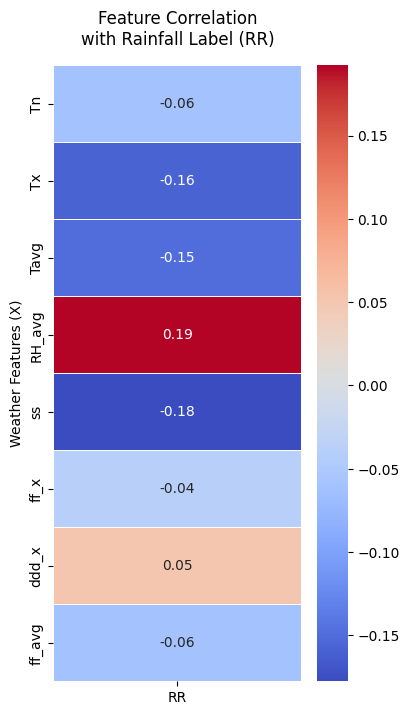

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 10))
full_correlation = df.corr(numeric_only=True)
label_corelation = full_correlation[['RR']].drop(index=['RR', 'station_id'])
plt.figure(figsize=(4, 8))
sns.heatmap(
    label_corelation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=True,
    linewidths=0.5
)

plt.title('Feature Correlation\nwith Rainfall Label (RR)', fontsize=12, pad=15)
plt.ylabel('Weather Features (X)')
plt.show()

Selanjutnya kami ingin mengetahui bentuk distribusi dari masing-masing fitur yang berbentuk numerikal oleh karena itu kami memanggil library python untuk melakukan plotting graph histogram untuk masing-masing fitur namun dapat dilihat dibawah setelah kami memanggil graph histogram untuk masing-masing fitur yang ingin di plot. hasilnya terlalu berbentuk aneh hal ini dikarenakan ada outlier yang bernilai sangat jauh dari nilai yang lain membuat graph menjadi terzoom out dan tidak terlihat. 

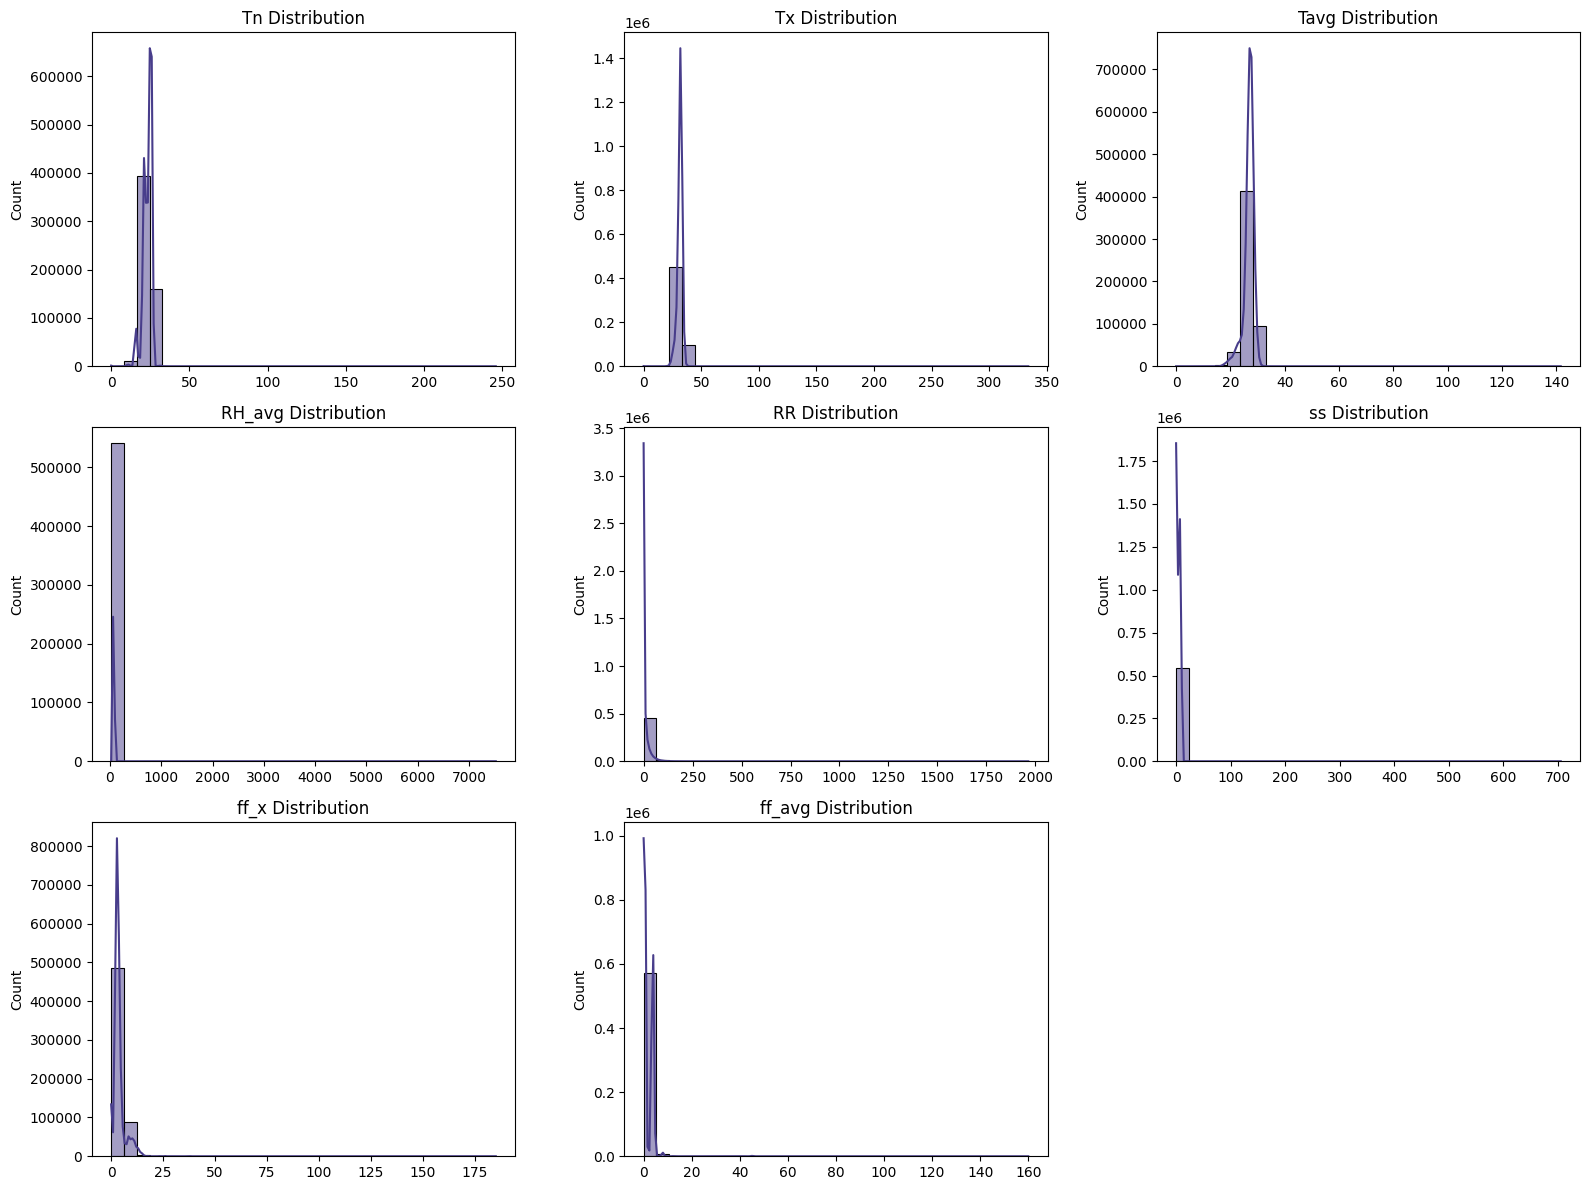

In [ ]:
features_to_plot = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):

    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='darkslateblue', bins=30)
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Untuk mengetahui secara pasti penyebab kenapa histogram graphnya berbentu terlalu kecil/zoom out kami memilih untuk menggunakan scatter plot untuk dapat melihat secara lebih jelas titik point sebuah data terletak sebagaimana jauhnya dikarenakan outlier dan dapat dilihat di hasil scatter plot bahwa memang ada outlier yang sangat besar sekali membuat graph menjadi menciut dan membuat tidak dapat dilihat bentuk distribusi datanya. 

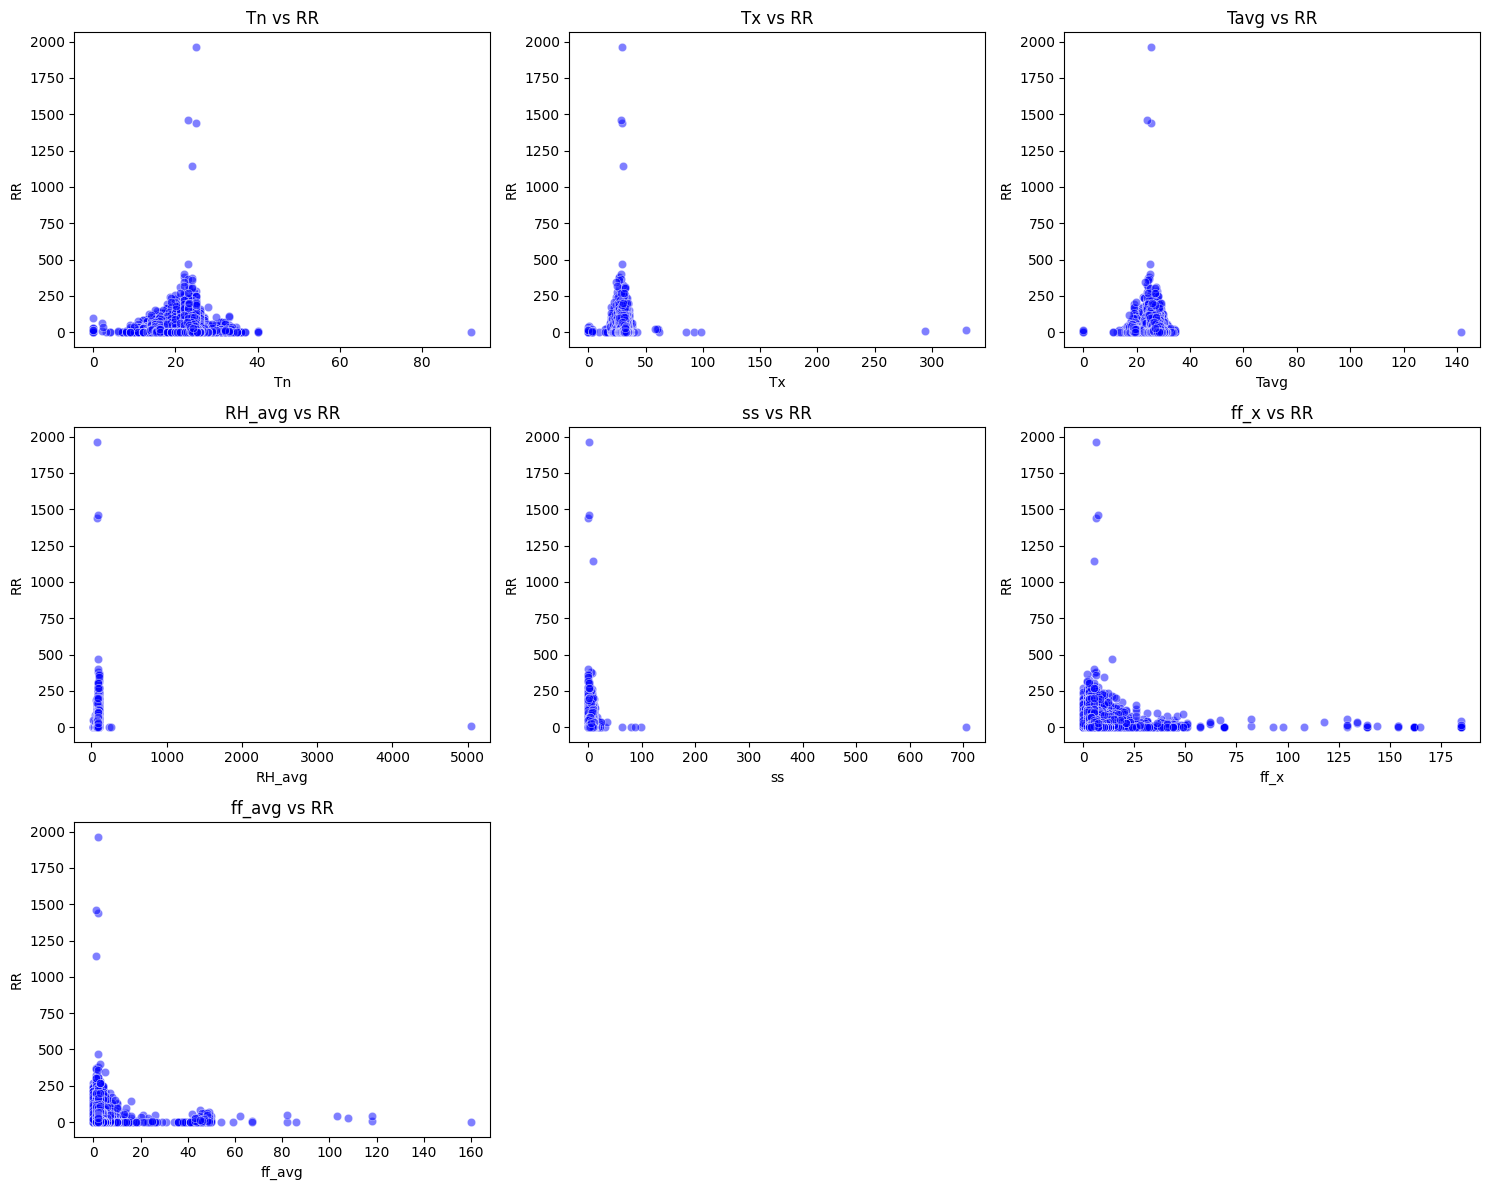

In [16]:
features = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ff_avg']
label = 'RR'

plt.figure(figsize=(15, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)

    sns.scatterplot(data=df, x=feature, y=label, alpha=0.5, color='b')

    plt.title(f'{feature} vs {label}')
    plt.xlabel(feature)
    plt.ylabel(label)


plt.tight_layout()
plt.show()

# Data Preprocessing

Dikarenakan data yang tidak bersih adanya missing values dan juga outlier yang sangat besar melakukan analisis dan pengertian data menjadi lebih susah terutama dalam pencarian bentuk distribusi data dari masing-masing fitur dikarenakan bentuk graphnya menjadi tidak terlihat. Oleh karena itu kami memilih untuk melakukan data preprocessing terlebih dahulu untuk dapat melakukan analisis data dengan lebih baik.

Pertama kami mengurus terlebih dahulu data yang memiliki missing values di salah satu kolom-kolomnya. Pertama kami mengubah data menjadi datetime dan mengurutkan data-data dari dataset menjadi kronologis. 

Lalu kami memberishkan data dengan cara data scrubbing dimana sebuah data pasti akan memiliki outlier dalam kasus kami outliernya sangat besar sekali oleh itu kami memberishkan datanya dengan cara memotong data yang diluar range tertentu yang masuk akal agar tidak ada data outlier yang mungkin disebabkan karena kondisi aneh yang terjadi pada suatu saat pencatatan data iklim. Hal ini kita lakukan juga agar graph tidak terlihat zoom out atau kecil dengan cara memotong sama halnya seperti melakukan zoom in pada graph memotong panjang sumbu x nya dengan melimit.

pertama membersihkan kolom suhu minimum atau Tn menjadi diantara 15 sampai 35 derajat saja dan bila terletak diluar range ini maka data tersebut akan diisi dengan null,
selanjutnya kita lakukan hal yang sama untuk rata-rata suhu atau Tavg menjadi diantara 15 sampai 40 derajat dan bila diluar range ini maka diisi dengan null,
selanjutnya kita lakukan hal yang sama juga untuk suhu maximum atau Tx menjadi diantara 20 sampai 45 derajat dan bila diluar range ini maka diisi dengan null.

lalu untuk kecepatan angin maksikum kami batasi agar angka tidak terlalu besar dimana kecepatan angin maximum menjadi diantara 0 m/s sampai 40 m/s dan sama seperti suhu bila diluar range ini maka akan dijadikan null

dan untuk sisanya seperti kelembapan yang berbentuk persentase maka tidak mungkin ada yang diatas 100% kelembapan oleh karena itu bila ada maka dijadikan null
dan untuk sunshine atau sinar matahari dalam satu hari karena indonesia terletak di garis khatulistiwa maka maximum mendapat sinar matahari dalam satu hari adalah 12 jam oleh itu bila lebih mak akana dilakukan pengisian null
dan terakhir untuk label yaitu RR atau tingkat curah hujan kami bataskan menjadi 500 melihat dari persebaran data yang didapat dari scatter plot dimana yang lebih dari 500 biasanya sampai 2x lipat atau lebih menandakan outlier yang sangat besar oleh karena itu kami berpikir 500 adalah garis tengah yang cocok untuk perpotongan outlier dan data normal.

Untuk mengisi kolom-kolom yang menjadi kosong dikarenakan dilakukannya data scrubbing ini maka kami akan menggunakan imputasi untuk memastikan tidak ada data yang memiliki missing values baik dikarenakan memang tidak ada dari awalnya didapatkan dataset atau dikarenakan data scrubbing ini.

Untuk imputasi kolom fitur numerik kami menggunakan interpolasi linear berdasarkan stasiun yang didapatkan dari stasiun id. kami melakukan hal ini menggunakan library pandas yang menyediakan fungsi interpolate untuk melakukan imputasi yang kami inginkan.

Untuk imputasi kolom kategorical yaitu arah angin terbanyak kami menggunakan forward/backward fill untuk masing-masing stasiun. 

dan sisanya untuk yang tidak dapat di imputasi kami melakukan dropna untuk memastikan tidak ada data yang kosong atau memiliki missing values

In [17]:
import numpy as np
import pandas as pd

print("Missing Values Sebelum Imputasi:")
print(df.isnull().sum())

# Langkah 1: Mengubah date menjadi datetime dan mengurutkan data secara kronologis
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df = df.sort_values(by=['station_id', 'date']).reset_index(drop=True)

# 1. Bersihkan Suhu Minimum (Tn): Normalnya di Indonesia berkisar 15 - 35 derajat
df.loc[(df['Tn'] < 15) | (df['Tn'] > 35), 'Tn'] = np.nan
df.loc[(df['Tavg'] < 15) | (df['Tavg'] > 40), 'Tavg'] = np.nan
# 2. Bersihkan Suhu Maksimum (Tx): Normalnya 20 - 45 derajat
df.loc[(df['Tx'] < 20) | (df['Tx'] > 45), 'Tx'] = np.nan

# 3. Bersihkan Kecepatan Angin Maksimum (ff_x): Batasi jika ada angka ekstrem
df.loc[(df['ff_x'] < 0) | (df['ff_x'] > 40), 'ff_x'] = np.nan

# 4. Batasan fisis lainnya
df.loc[df['RH_avg'] > 100, 'RH_avg'] = np.nan
df.loc[df['ss'] > 12, 'ss'] = np.nan
df.loc[df['RR'] > 500, 'RR'] = np.nan

# Langkah 2: Imputasi Fitur Numerik menggunakan Interpolasi Linear per Stasiun
kolom_numerik = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg']
df[kolom_numerik] = df.groupby('station_id')[kolom_numerik].transform(
    lambda x: x.interpolate(method='linear', limit=7, limit_direction='forward')
)

# Langkah 3: Imputasi Fitur Kategorik (Arah Angin) menggunakan Forward/Backward Fill per Stasiun
df['ddd_car'] = df.groupby('station_id')['ddd_car'].transform(
    lambda x: x.ffill(limit=7)
)
df = df.dropna(subset=kolom_numerik)

print("\nMissing Values Setelah Imputasi:")
print(df.isnull().sum())

Missing Values Sebelum Imputasi:
date               0
Tn             23383
Tx             37736
Tavg           45105
RH_avg         48182
RR            125384
ss             43721
ff_x           10214
ddd_x          13128
ff_avg         10127
ddd_car        13739
station_id         0
dtype: int64

Missing Values Setelah Imputasi:
date             0
Tn               0
Tx               0
Tavg             0
RH_avg           0
RR               0
ss               0
ff_x             0
ddd_x            0
ff_avg           0
ddd_car       1341
station_id       0
dtype: int64


Setelah dilakukan scrubbing dan imputasi data dan juga pengahpusan data untuk mengurus missing values dapat dilihat total jumlah data pada dataset berjumalh 518571

In [18]:
print(f"Shape data setelah perbaikan missing value: {df.shape}")

Shape data setelah perbaikan missing value: (518571, 12)


Setelah sudah melakukan datascrubbing kami melakukan plotting lagi untuk menganalisis korelasi data antara fitur dengan label menggunakan heatmap sama seperti di tahap atas namun kita memastikan menjalankannya kembali setelah dilakukan imputasi data agar mengupdate korelasi agar tetap sesuai dengan data yang baru diberisihkan caranya sama seperti pemanggilan library seaborn heatmap pada tahap sebelumnya dan hasilnya adalah berikut.

<Figure size 1400x1000 with 0 Axes>

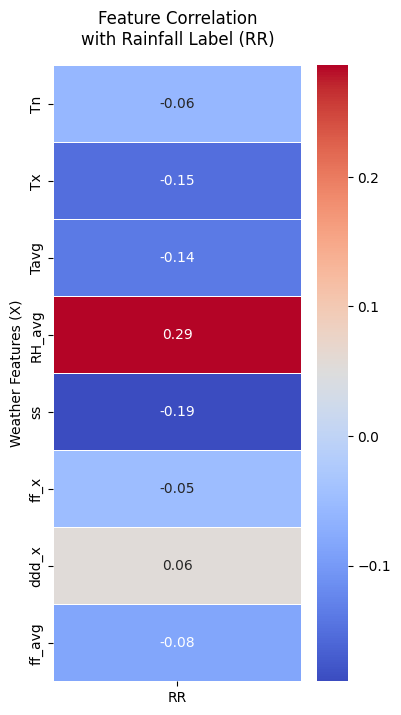

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 10))
full_correlation = df.corr(numeric_only=True)
label_corelation = full_correlation[['RR']].drop(index=['RR', 'station_id'])
plt.figure(figsize=(4, 8))
sns.heatmap(
    label_corelation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=True,
    linewidths=0.5
)

plt.title('Feature Correlation\nwith Rainfall Label (RR)', fontsize=12, pad=15)
plt.ylabel('Weather Features (X)')
plt.show()

Kami ingin mengecek tingkat curah hujan berdasarkan kolom yang bukan numerik dan juga kategorikal yaitu berdasarkan bulan untuk mengetahui korealsinya dikarenakan penasaran, kami melakukan plotting antara tingkat curah hujan dengan bulan dari januari 1 sampai desember 12. dan hasilnya dapat dilihat dibawah:

In [21]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Hubungannya dengan target: Mari kita lihat rata-rata curah hujan tiap bulannya
print("Rata-rata curah hujan (RR) per bulan:")
print(df.groupby('month')['RR'].mean())

Rata-rata curah hujan (RR) per bulan:
month
1     10.737939
2     10.352723
3      9.735928
4      9.533793
5      8.484962
6      7.356428
7      6.280684
8      5.328318
9      6.032122
10     7.179349
11     9.780173
12    11.302515
Name: RR, dtype: float64


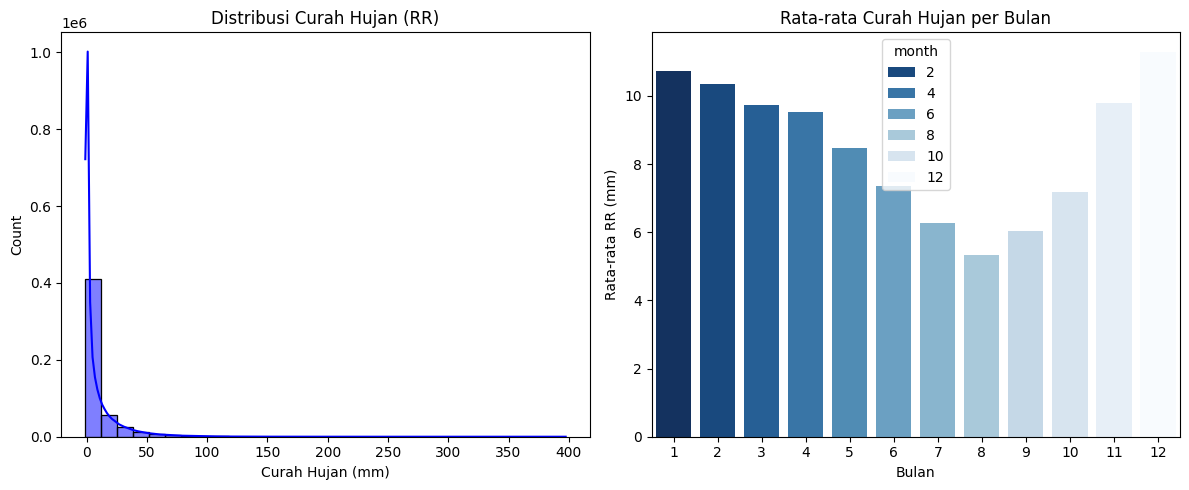

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['RR'], bins=30, kde=True, color='blue')
plt.title('Distribusi Curah Hujan (RR)')
plt.xlabel('Curah Hujan (mm)')
plt.subplot(1, 2, 2)

monthly_rain = df.groupby('month')['RR'].mean().reset_index()
sns.barplot(x='month', y='RR', data=monthly_rain, palette='Blues_r', hue="month")
plt.title('Rata-rata Curah Hujan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata RR (mm)')

plt.tight_layout()
plt.show()

Untuk fitur kategorikal yaitu adalah frekuensi kemunculan arah angin terbanyak yang disimpan pada kolom ddd_car kami ingin melihat mana yang paling sering muncul, dan untuk mengetahuinya kamu menjalankan kode berikut yang menghitung jumlah kemunculan arah angin di setiap data dan memetaknnya dalam bentuk graph untuk melihat kemunculan arah angin terbanyak dengan sumbu y nya adalah count berapa banyak arah mata angin itu ada di dataset. 

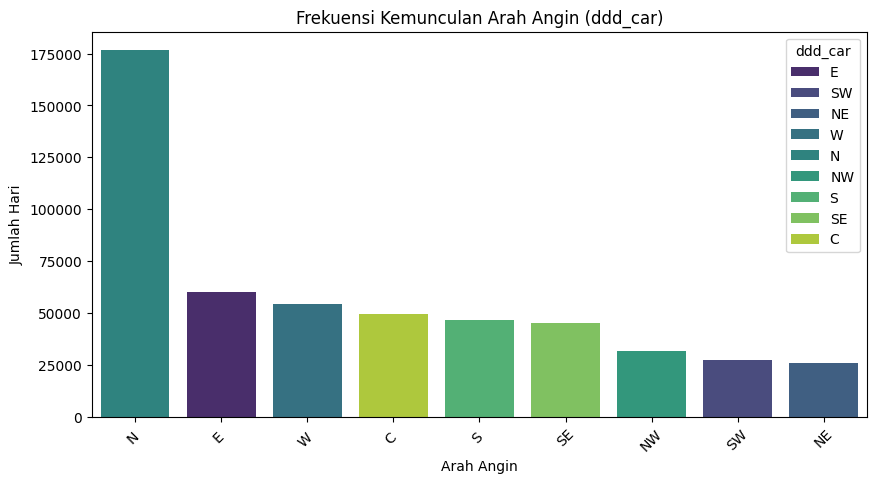

In [27]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ddd_car', order=df['ddd_car'].value_counts().index, palette='viridis', hue="ddd_car")
plt.title('Frekuensi Kemunculan Arah Angin (ddd_car)')
plt.xlabel('Arah Angin')
plt.ylabel('Jumlah Hari')
plt.xticks(rotation=45)
plt.show()

Setelah melakukan data scrubbing dan imputation sekarang kami ingin melakukan analisis persebaran atau distribusi fitur/kolom numerikal dalam dataset yang awalnya tidak terlalu kelihatan dikarenakan outlier yang sangat besar atau jauh membuat sumbu x menjadi terlalu ter zoom out dan juga angkanya tidak sesuai dengan dunia nyata dengan dilakukan scrubbing dan pemotongan sekarang kami melakukan pemanggilan function plot histrogram dan juga scatterplot kembali untuk melihat persebaran masing-masing fitur. Kami juga memanggil plotting boxplot untuk melihat outlier yang tidak se-extreme sebelumnya memiliki jarak sebarapa jauh, hal ini kami lakukan untuk melakukan analis outlier dari dataset agar dapat kita lakukan normalisasi untuk menanggapi outlier yang ada setelah dilakukan scrubbing sebelumnya dan hasilnya dapat dilihat dibawah: 

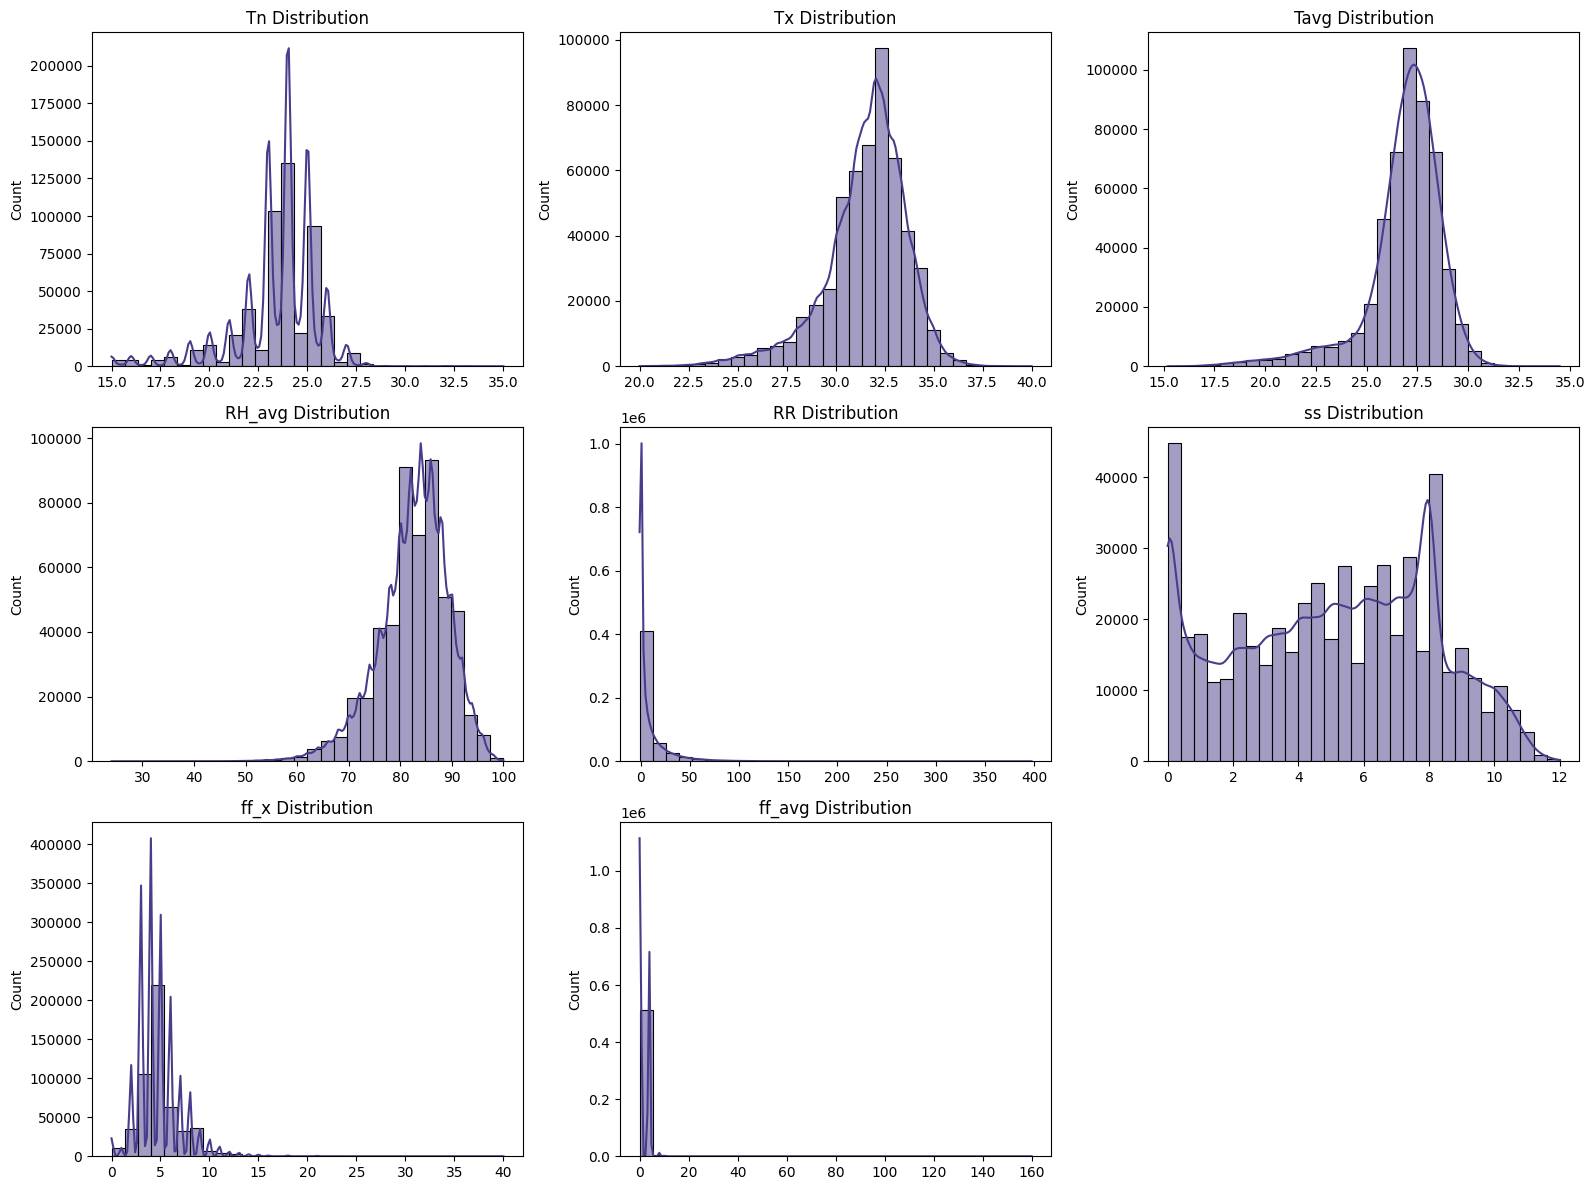

In [28]:
features_to_plot = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):

    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='darkslateblue', bins=30)
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')


axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

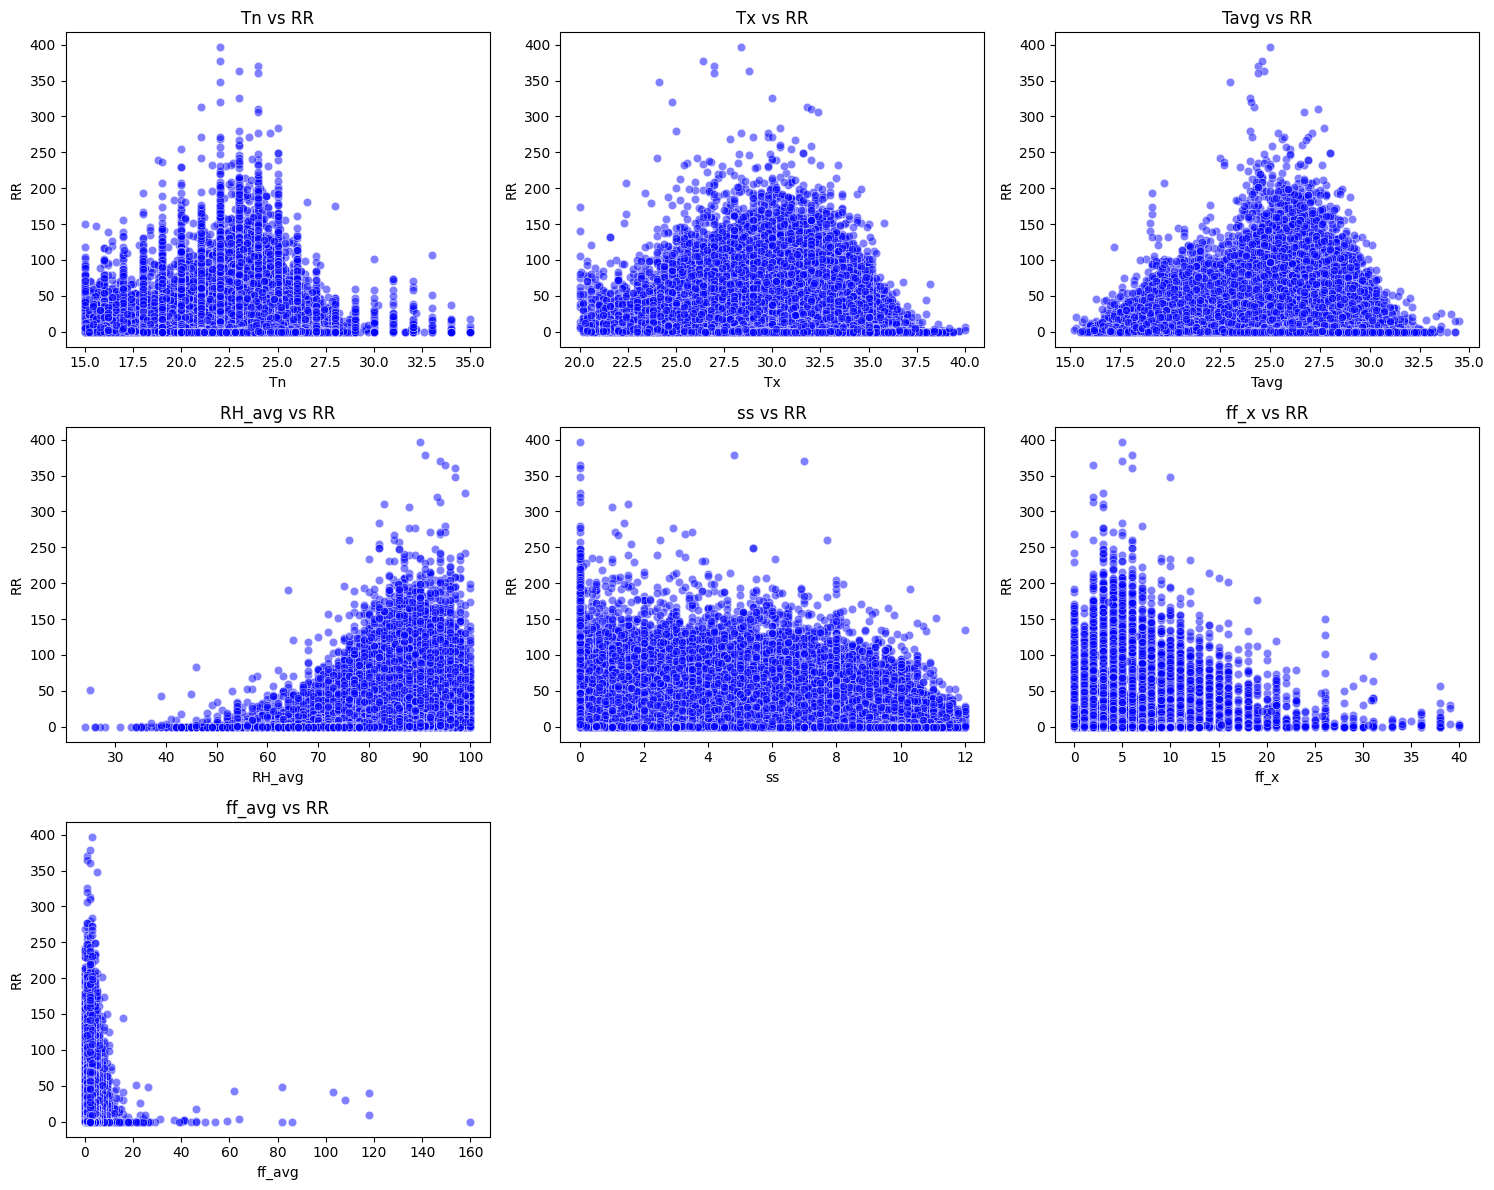

In [29]:
features = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ff_avg']
label = 'RR'

# Mengatur ukuran figure (keseluruhan kanvas)
plt.figure(figsize=(15, 12))

# Looping melalui semua fitur untuk membuat subplot masing-masing
for i, feature in enumerate(features, 1):
    # Membuat grid subplot ukuran 3 baris x 3 kolom
    plt.subplot(3, 3, i)

    # Membuat scatter plot
    sns.scatterplot(data=df, x=feature, y=label, alpha=0.5, color='b')

    # Memberi judul dan label pada sumbu
    plt.title(f'{feature} vs {label}')
    plt.xlabel(feature)
    plt.ylabel(label)

# Menyesuaikan jarak antar subplot agar tidak tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()


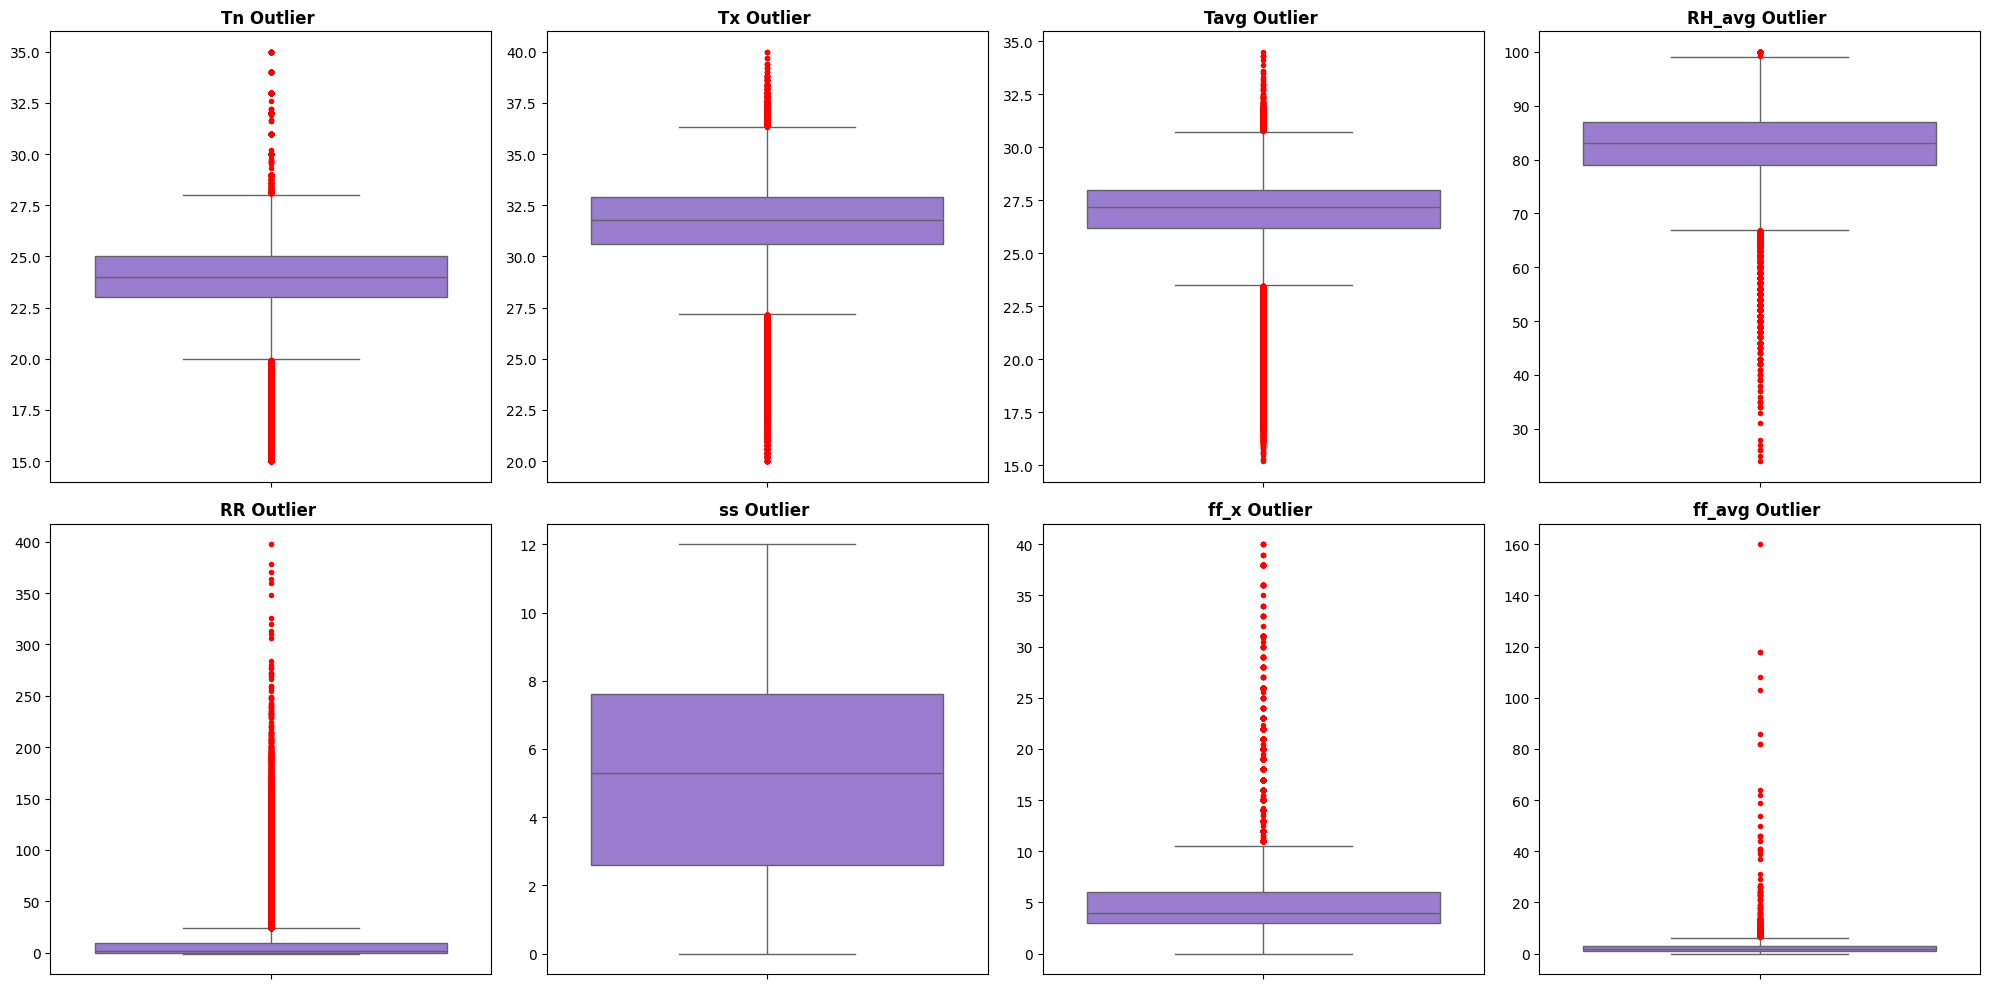

In [30]:
features_to_box = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_box):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color='mediumpurple',
        flierprops={'markerfacecolor': 'red', 'markersize': 4, 'markeredgecolor': 'none'}
    )
    axes[i].set_title(f'{col} Outlier ', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Hasil dari analisis pembuatan graphing dan plotting diatas dapat kami simpulkan bahwa masing masing distribusi dari fitur adalah sebagai berikut:
| Kolom/Fitur | Tipe Distribusi |
| --- | --- |
| Tn | Normal |
| Tx | Normal |
| Tavg | Normal |
| RH_avg | Normal |
| RR | Log |
| ss | Uniform |
| ff_x | Normal |
| ff-avg | Normal |


Selanjutnya kami ingin melakukan kategorikal data encoding untuk fitur ddd_car atau arah mata angin terbanyak karena bentuknya adalah sebuah string yang menunjukan arah mata angin, kami ingin melakukan one hot encoding untuk fitur berikut dikarenakan kami rasa fitur ini akan berpengaruh pada angka tingkat curah hujan. Pertama yang kita lakukan adalah mengubah ddd_car dari string menjadi int menggunakan fitur yang disediakan library pandas dan gabungkan ke dataframe dataset dan membuang ddd_car yang belum dilakukan encoding atau masih berbentuk string. 

In [31]:
ddd_car_encoded = pd.get_dummies(df['ddd_car'], prefix='ddd_car', dtype=int)
df = pd.concat([df, ddd_car_encoded], axis=1)
df = df.drop('ddd_car', axis=1)

Lalu kami melaukan analis sama seprti ke data numerikal sebelumnya ke fitur arah mata angin terbanyak yang baru saja dilakukan one hot encoding. Pertama kami ingin memastikan apakah hubungan masing-masing arah mata angin ke tingkat curah hujan. Hubungannya kami analisis dengan menggunakna graph heatmap untuk melihat korelasi berhubungan atau berbanding terbalik dari masing-masing arah mata angin yang kami berhasil encoding. Dapat dilihat hasil graphnya dibawah ini:

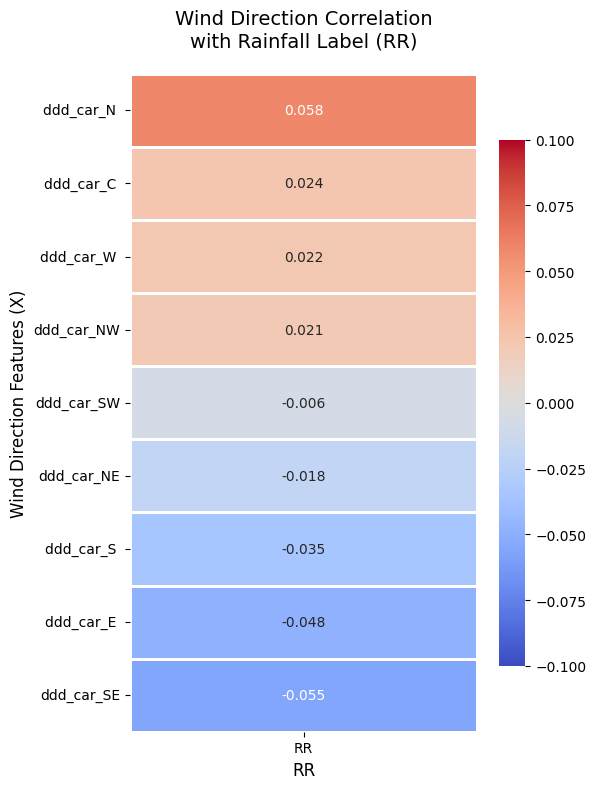

In [32]:
wind_features = [col for col in df.columns if col.startswith('ddd_car_')]
correlation_wind = df[wind_features + ['RR']].corr()[['RR']].drop('RR')
correlation_wind = correlation_wind.sort_values(by='RR', ascending=False)
plt.figure(figsize=(6, 8))

sns.heatmap(
    correlation_wind,
    annot=True,            
    cmap='coolwarm',        
    fmt=".3f",              
    linewidths=0.8,         
    linecolor='white',
    vmin=-0.1,              
    vmax=0.1,             
    cbar_kws={"shrink": 0.8}
)

plt.title('Wind Direction Correlation\nwith Rainfall Label (RR)', fontsize=14, pad=20, fontweight='medium')
plt.ylabel('Wind Direction Features (X)', fontsize=12)
plt.xlabel('RR', fontsize=12)

plt.tight_layout()
plt.show()

Selanjutnya setelah kami sudah dapat melakukan encoding data kategorikal dan melihat hubungannya dengan label, dan juga kami sudah dapat melihat distribusi dari masing-masing fitur numerikal sekarang kami akan melakukan normalization/standarization, kami memilih teknik yang berbeda untuk masing-masing fitur berdasarkan dari jenis distribusi yang didapatkan dari analisis distribusid sebelumnya menggunakan histogram. Dan dari analisis distribusi kami, kami akan menggunakan teknik standarization/normalization berikut untuk masing-masing fitur:

| Kolom/Fitur | Teknik Normalization |
| --- | --- |
| Tn | z-score scalling |
| Tx | z-score scalling |
| Tavg | z-score scalling |
| RH_avg | z-score scalling |
| RR | log scalling |
| ss | linear scalling |
| ff_x | z-score scalling |
| ff_avg | z-score scalling |

Selanjutnya setelah kami melakukan normalization pada masing-masing fitur numerikal kami akan melakukan feature selection hal ini kami lakukan dengan menggunakan L1 normalization untuk dapat menghapus fitur yang memang tidak terlalu berhubungan dengan label, kami memilih L1 untuk mengurangi jumlah fitur agar tidak terlalu banyak terutama dikarenakan tambahan fitur dari encoding ddd_car menggunakan one-hot encoding yang membuat fitur menjadi cukup banyak oleh karena itu kami menggunakan L1 normalization. 

Kami juga melakukan train test split dengan persebaran dari dataset aslinya 50% untuk training 25% validating dan 25% untuk testing.

c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Fitur yang dipilih lasso:
- Tn
- Tx
- Tavg
- RH_avg
- ss
- ff_x
- ddd_x
- ff_avg
- month
- year
- ddd_car_E 
- ddd_car_N 
- ddd_car_NW
- ddd_car_S 
- ddd_car_SE
- ddd_car_W 

Total fitur terpilih: 16 dari 19



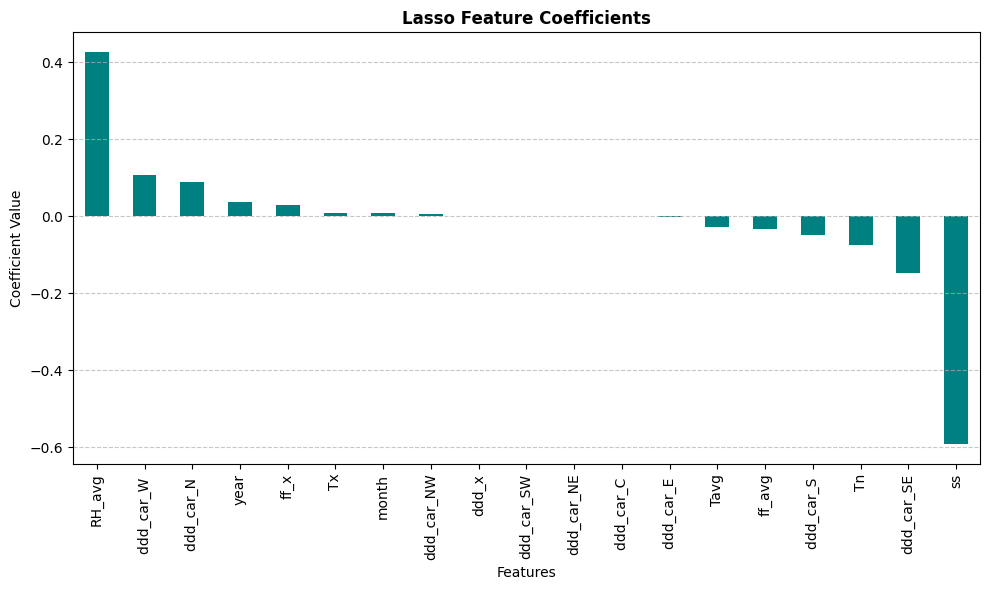

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# PERSIAPAN DATA & TARGET LOG SCALING

y = np.log1p(df["RR"])
X = df.drop(columns=["date", "RR", "station_id"])

for col in X.select_dtypes(include="bool").columns:
    X[col] = X[col].astype(int)

X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data.drop(columns=["RR"])
y = combined_data["RR"]

# SPLIT 50% / 25% / 25%

total_rows = len(X)
batas_train = int(total_rows * 0.50)
batas_val = int(total_rows * 0.75)

X_train, y_train = X.iloc[:batas_train].copy(), y.iloc[:batas_train].copy()
X_val, y_val     = X.iloc[batas_train:batas_val].copy(), y.iloc[batas_train:batas_val].copy()
X_test, y_test   = X.iloc[batas_val:].copy(), y.iloc[batas_val:].copy()


# PROSES MULTI-SCALING FITUR X

fitur_zscore = ["Tn", "Tx", "Tavg", "RH_avg", "ff_x", "ff_avg"]
fitur_linear = ["ss"]

scaler_zscore = StandardScaler()
scaler_linear = MinMaxScaler()

X_train[fitur_zscore] = scaler_zscore.fit_transform(X_train[fitur_zscore])
X_train[fitur_linear] = scaler_linear.fit_transform(X_train[fitur_linear])

X_val[fitur_zscore] = scaler_zscore.transform(X_val[fitur_zscore])
X_val[fitur_linear] = scaler_linear.transform(X_val[fitur_linear])

X_test[fitur_zscore] = scaler_zscore.transform(X_test[fitur_zscore])
X_test[fitur_linear] = scaler_linear.transform(X_test[fitur_linear])

# TRAINING LASSO REGRESSION FOR FEATURE SELECTION

lasso = Lasso(alpha=0.001, random_state=42)
lasso.fit(X_train, y_train)

feature_coefficients = pd.Series(lasso.coef_, index=X.columns)
selected_features = feature_coefficients[feature_coefficients != 0].index.tolist()

print("Fitur yang dipilih lasso:")
for feature in selected_features:
    print(f"- {feature}")
print(f"\nTotal fitur terpilih: {len(selected_features)} dari {len(X.columns)}\n")

X_train_lasso = X_train[selected_features]
X_val_lasso = X_val[selected_features]
X_test_lasso = X_test[selected_features]

# VISUALISASI KOEFISIEN FITUR

plt.figure(figsize=(10, 6))
feature_coefficients.sort_values(ascending=False).plot(kind="bar", color="teal")
plt.title("Lasso Feature Coefficients", fontsize=12, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Dapat dilihat diatas bahwa lasso feature selection menghasilkan sebagai berikut dimana fitur yang di drop adalah sebagai berikut:
| Fitur yang di drop | 
| --- |
| ddd_x |
| ddd_car_SW |
| ddd_car_NE | 

kami juga melakuan observasi terhadap fitur yang memiliki koefisien tertinggi dan terendah atau yang paling berpengaruh dan berpengaruh terbalik dapat dilihat bahwa kelembapan sangat berpengaruh dan hal tersebut sesuai intuisi dimana kelembapan udara berpengaruh dengan adanya curah hujan yang lebih tinggi, dan untuk ss atau sunshine juga sangat berpengaruh terbalik dimana bila suatu hari memiliki sinar matahari lebih lama berarti tidak ada awan yang menyebabkan hujan. 

Kami juga melakukan banyak plotting untuk masing-masing fitur di masing-masing dataset split untuk melihat korelasinya dengan tingkat curah hujan atau RR, kami melakukan ini untuk melihat bagaimana persebaran dataset setelah dilakukan split secara random. dan hasilnya adalah sebagai berikut dimana persebaran dari masing-masing split ada perbedaanya.

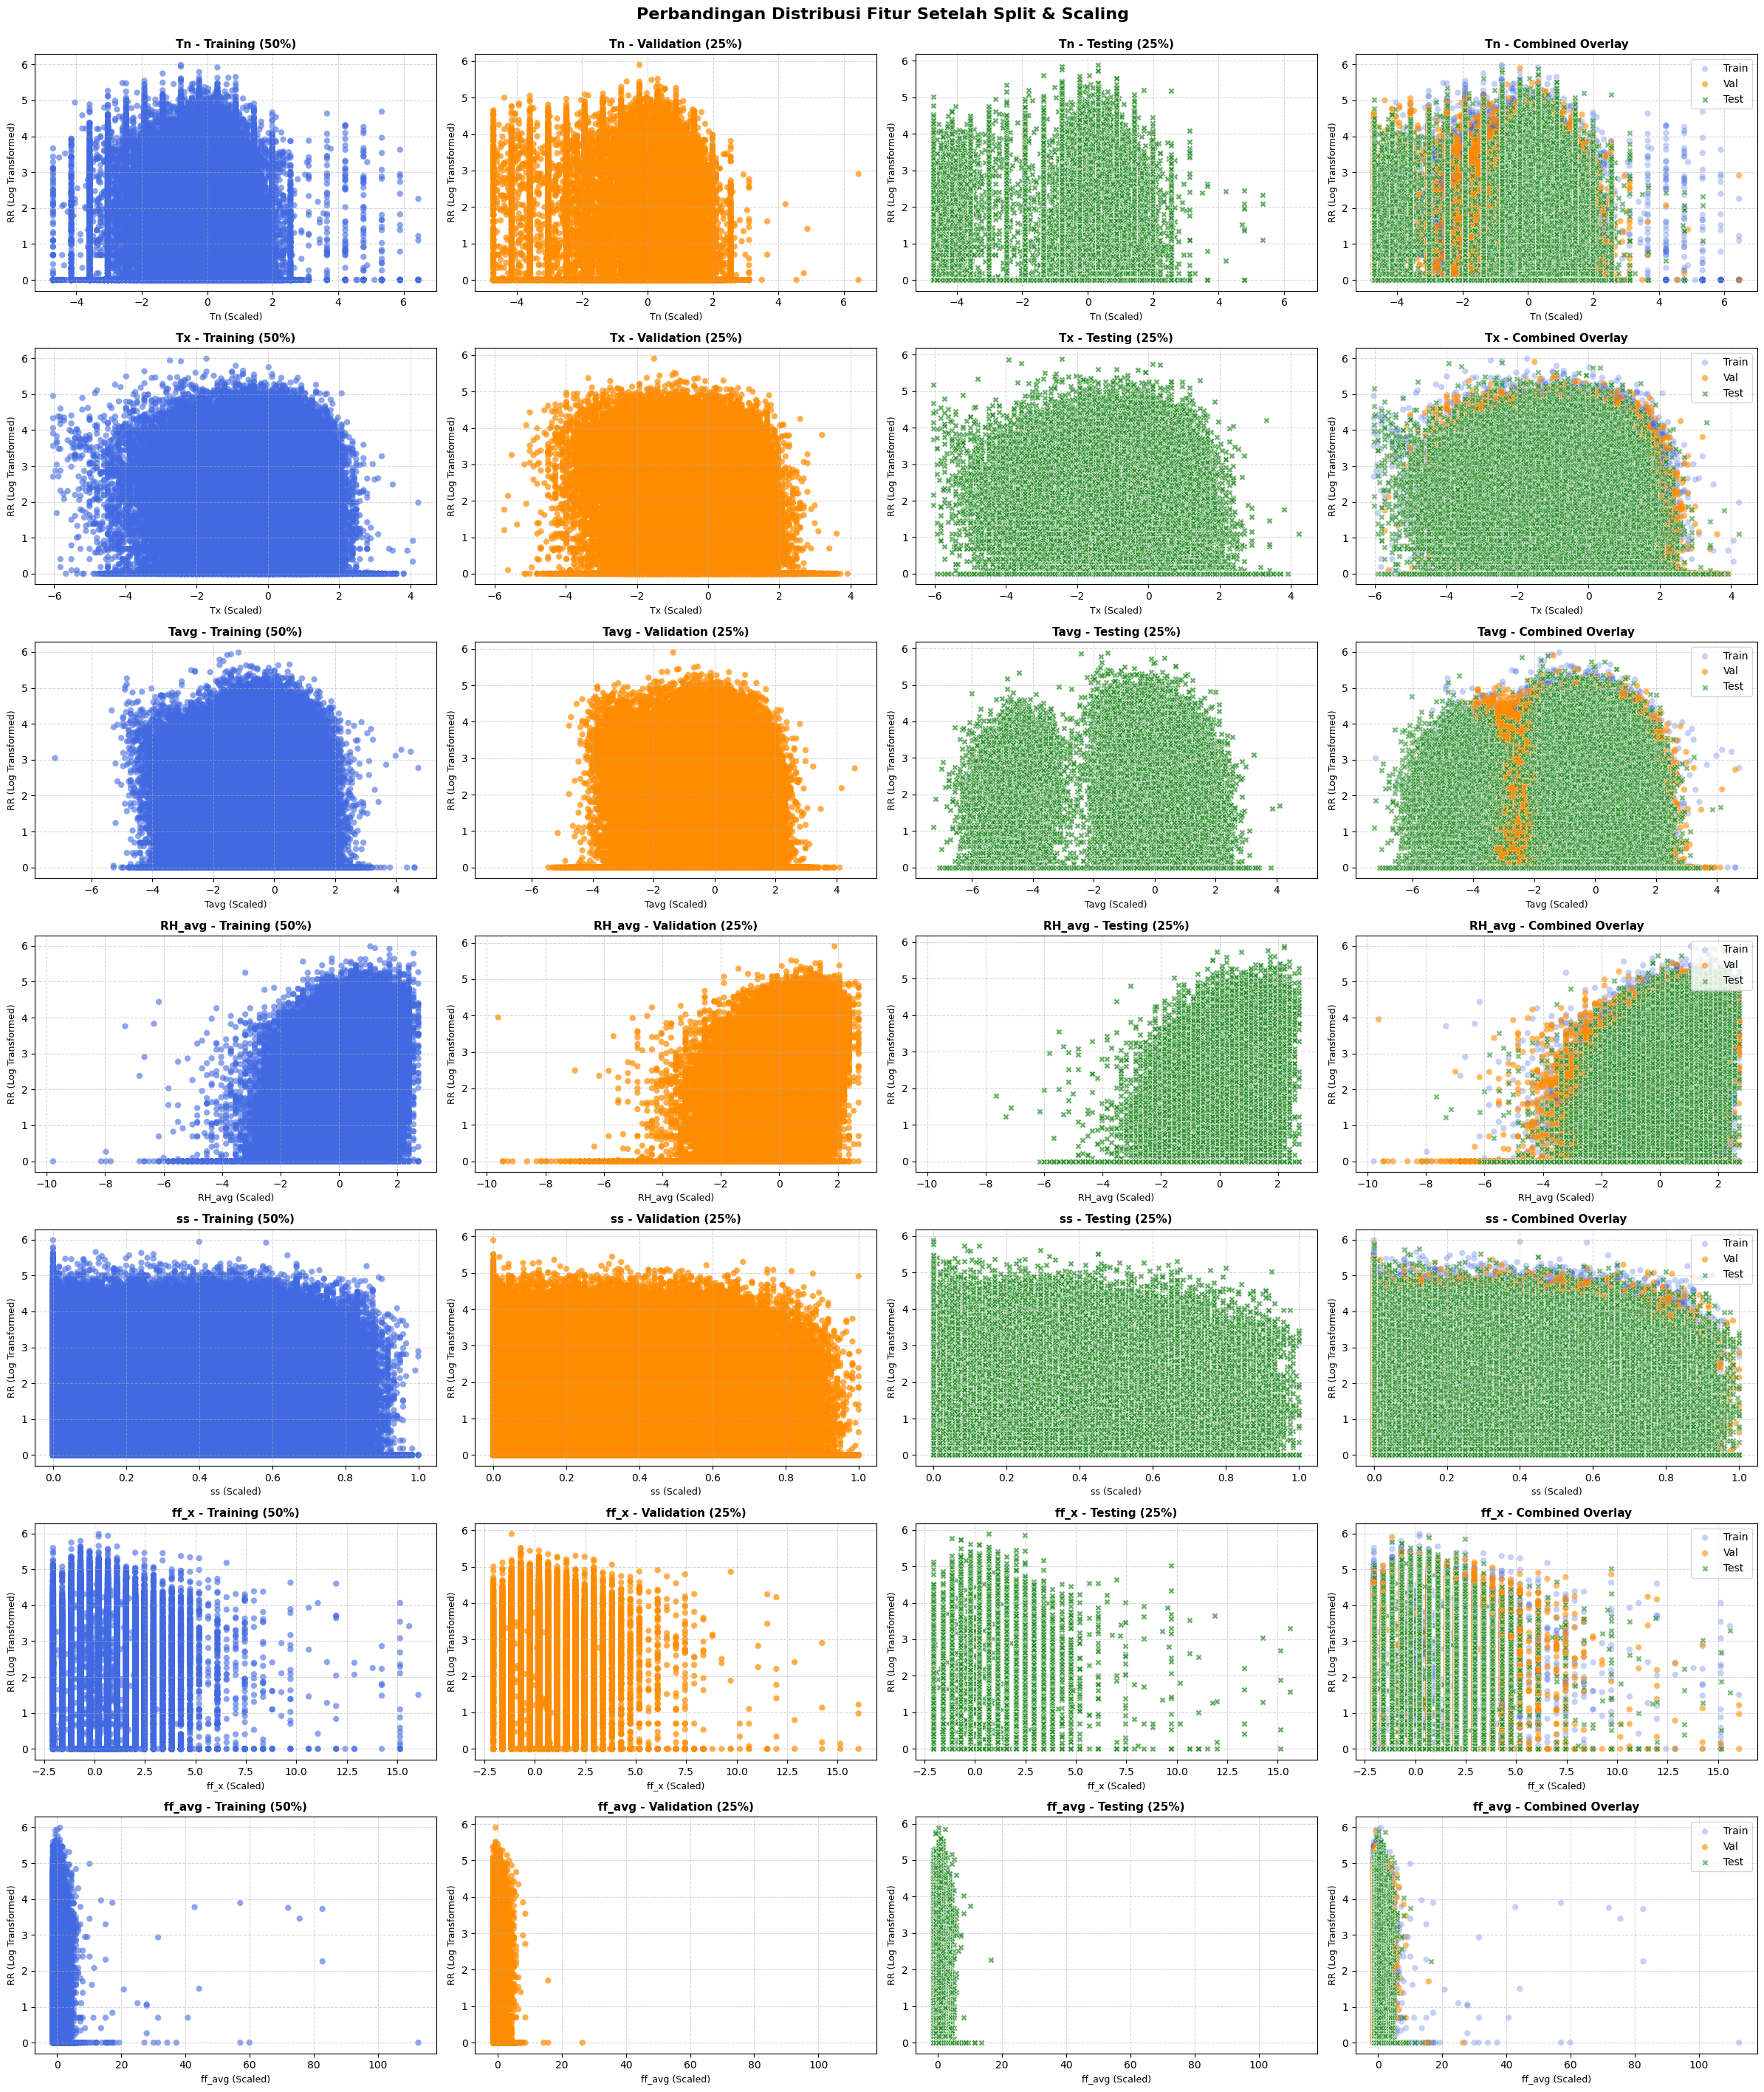

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ["Tn", "Tx", "Tavg", "RH_avg", "ss", "ff_x", "ff_avg"]
label = "RR"

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=4,
    figsize=(24, 4 * len(features_to_plot)),
    sharex='row'
)

for idx, feature in enumerate(features_to_plot):

    # KOLOM 1: KHUSUS TRAINING (50%)
    sns.scatterplot(
        x=X_train[feature],
        y=y_train,
        ax=axes[idx, 0],
        color="royalblue",
        alpha=0.6,
        edgecolor="none",
    )
    axes[idx, 0].set_title(f"{feature} - Training (50%)", fontsize=11, fontweight="bold")

    # KOLOM 2: KHUSUS VALIDATION (25%)
    sns.scatterplot(
        x=X_val[feature],
        y=y_val,
        ax=axes[idx, 1],
        color="darkorange",
        alpha=0.7,
        edgecolor="none",
    )
    axes[idx, 1].set_title(f"{feature} - Validation (25%)", fontsize=11, fontweight="bold")

    # KOLOM 3: KHUSUS TESTING (25%)
    sns.scatterplot(
        x=X_test[feature],
        y=y_test,
        ax=axes[idx, 2],
        color="forestgreen",
        alpha=0.7,
        marker="X",
    )
    axes[idx, 2].set_title(f"{feature} - Testing (25%)", fontsize=11, fontweight="bold")

    # KOLOM 4: GABUNGAN UNTUK PERBANDINGAN
    sns.scatterplot(
        x=X_train[feature],
        y=y_train,
        ax=axes[idx, 3],
        color="royalblue",
        alpha=0.3,
        label="Train",
        edgecolor="none",
    )
    sns.scatterplot(
        x=X_val[feature],
        y=y_val,
        ax=axes[idx, 3],
        color="darkorange",
        alpha=0.6,
        label="Val",
        edgecolor="none",
    )
    sns.scatterplot(
        x=X_test[feature],
        y=y_test,
        ax=axes[idx, 3],
        color="forestgreen",
        alpha=0.6,
        label="Test",
        marker="X",
    )
    axes[idx, 3].set_title(f"{feature} - Combined Overlay", fontsize=11, fontweight="bold")
    axes[idx, 3].legend(loc="upper right", frameon=True)

    for col_idx in range(4):
        axes[idx, col_idx].set_xlabel(f"{feature} (Scaled)", fontsize=9)
        axes[idx, col_idx].set_ylabel(f"{label} (Log Transformed)", fontsize=9)
        axes[idx, col_idx].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.suptitle("Perbandingan Distribusi Fitur Setelah Split & Scaling", fontsize=16, fontweight="bold", y=1.01)
plt.show()

# Modeling

Sebelum masuk kedalam modelling dan menjalankan model tersebut kami pertama menentukan dulu cara mengevaluasi apakah sebuah model dapat dibilang baik atau tidak baik secara kuantitatif kami melakukan hal tersebut dengan menggunakan metrik yang sesuai untuk model reggresion kami yaitu sebagai berikut:
| Evaluation Metric | Penjelasan |
| --- | --- |
| MAE | Mengevaluasikan error dengan cara, menghitung rata-rata dari selisih mutlak antara hasil prediksi model dengan label dari dataset sebenarnya |
| RMSE | Mengevaluasikan error dengan cara, menghitung setiap selisih error-errornya dikuadratkan baru di rata-rata dan setelah itu diakarkan |
| R^2 Score | Fungsinya adalah untuk mengevaluasikan model apakah pintar atau tidak dengan memberikan angka diatnara 0 sampai 1 dimana lebih basar maka model lebih pintar/akurat | 

## Gradient Boosting

Kami memilih pertama untuk menggunakan algoritma machine learning regression yaitu gradient boosting dikarenakan persebaran data yang tidak berbentuk linear.  

 - Kami memliki dataset yang cukup tersebar. gradient boosting dirancang dapat menebak titik-titik yang meleset di sebuah tebakan awal. Setiap pohon baru yang dibuat akan menyesuaikan dirinya untuk memperbaiki titik-titik label yang gagal ditebak oleh pohon sebelumnya, membuat masing-masing iterasi menjadi semakin membentuk dataset yang ada meskipun dataset ini memliki persebaran yang non linear dan nampak tanpa bentuk.
 - Gradient boosting cocok digunakan untuk dataset yang tidak berpola tidak seperti linear regression yang dimana sebuah korelasi data harus terletak dalam sebuah garis linear.
 - Gradient boosting memliliki hyperparameter learning rate membuat algoritma ini sangat dapat disetelel kecepatan dia menyesuaikan untuk masing-masing pohon yang dia buat.

Kami menggunakan library sklearn untuk menjalankan algoritma gradient boosting dimana pada library ini kami dapat memberikan hyperparameter dalam bentuk variable objek yang didalamnya mengandung masing-masing hyperparameter yaitu adalah:

| Hyperparameter | Pengertian |
| --- | --- |
| n_estimators | banyak pohon learning |
| learning rate | seberapa pohon seterusnya akan berpengaruh |
| max_depth | seberapa kedalaman pohon |
| min_sample_leaf | minimum sample data yang harus ada di leaf node |
| subsample | bagian dari training sample diambil menjadi pohon |
| max_features | cara menentukan split terbaik |
| random_state | seed untuk random |

kami memilih angka berikut dibawah sebagai percobaan pertama atau baseline yang nanti akan dilkakan hyperparameter tuning agar dapat mendapat model yang lebih baik dengan hyperparameter yang lebih cocok sementara dipilih angka berikut untuk dapat memastikan algoritma dapat berjalan. 

Kami menggunakan fitur yang berhasil diambil oleh L1 norm dan kami mengambil y prediksi untuk dimasukan ke algoritma yaitu adalah label RR. 

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
gb_model_standar = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=7,
    min_samples_leaf=5,
    subsample=0.8,
    max_features='sqrt',
    random_state=67
)

# PELATIHAN MODEL

gb_model_standar.fit(X_train_lasso, y_train)

# PREDIKSI & KEMBALIKAN KE SKALA MILIMETER ASLI

y_pred_log_gb = gb_model_standar.predict(X_val_lasso)
y_pred_asli_gb = np.expm1(y_pred_log_gb)
y_val_asli = np.expm1(y_val)

# EVALUASI

mae_gb = mean_absolute_error(y_val_asli, y_pred_asli_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_gb))
r2_gb = r2_score(y_val_asli, y_pred_asli_gb)

print("Evaluasi Gradient Boosting:")
print(f"MAE       : {mae_gb:.2f} mm")
print(f"RMSE      : {rmse_gb:.2f} mm")
print(f"R-squared : {r2_gb:.4f}")

Evaluasi Gradient Boosting:
MAE       : 7.14 mm
RMSE      : 15.54 mm
R-squared : 0.0199


Kami ingin melihat akurasi dari model gradient boosting secara langsung dalam bentuk graph yang memetakan hasil tebakan label dengan label yang sebenerannya, oleh karena itu kami memliih untuk membuat graph yang dapat memberikan gambaran lebih jelas untuk akurasi dari algoritma yang kami gunakan dibandingkan dengan angka saja. Pertama kami melakukan plotting seluruh tebakan label dengan label yang semestinya dimana diberikan garis merah yang menunjukan tebakan sempurna dan plotting tebakan dari model. 

Lalu kami membuat line plot untuk melihat akurasi dari tebakan model bila dipetakan berdasarkan harian/kronologis dimana menyesuaikan dari datenya, kami membuat graph ini untuk melihat bila model ini di deploy menjadi sebuah model yang dapat dipakai untuk benar-benar menebak tingkat curah hujan harian dalam sebuah aplikasi akan seperti apa akurasinya.

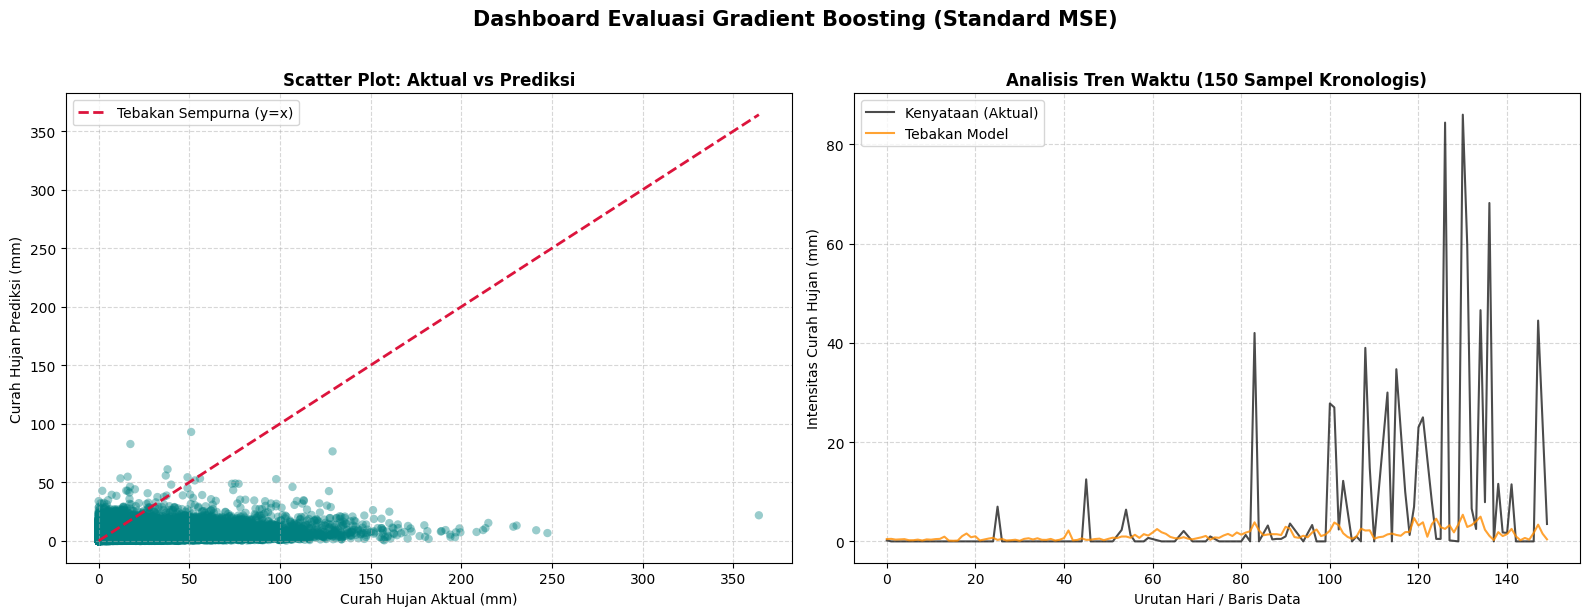

In [38]:
import matplotlib.pyplot as plt

y_val_asli_arr = np.array(y_val_asli)
y_pred_asli_arr = np.array(y_pred_asli_gb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
axes[0].scatter(y_val_asli_arr, y_pred_asli_arr, alpha=0.4, color='teal', edgecolors='none')
max_val = max(np.max(y_val_asli_arr), np.max(y_pred_asli_arr))
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2, label='Tebakan Sempurna (y=x)')
axes[0].set_title('Scatter Plot: Aktual vs Prediksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Curah Hujan Aktual (mm)', fontsize=10)
axes[0].set_ylabel('Curah Hujan Prediksi (mm)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Line Plot
jumlah_sampel = 150
axes[1].plot(y_val_asli_arr[:jumlah_sampel], label='Kenyataan (Aktual)', color='black', alpha=0.7, linewidth=1.5)
axes[1].plot(y_pred_asli_arr[:jumlah_sampel], label='Tebakan Model', color='darkorange', alpha=0.8, linewidth=1.5)
axes[1].set_title(f'Analisis Tren Waktu ({jumlah_sampel} Sampel Kronologis)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Urutan Hari / Baris Data', fontsize=10)
axes[1].set_ylabel('Intensitas Curah Hujan (mm)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle('Dashboard Evaluasi Gradient Boosting (Standard MSE)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Decision Tree

Untuk algoritma selanjutnya yang kami pilih adallah Decision tree dimana algoritma ini lebih sederhana dibandingkan gradient boosting kami memlihnya karena lebih simple dari gradient boosting namun tetap dapat menebak dataset yang hubungannya tidak linear. 

- Decision tree memotong data ke dalam kotak-kotak kondisi seperti if else , oleh karena tebakannya bisa bila datasetnya tidak linear karena mencari dengan cara membagi-bagi dataset ke petak petak dan bisa saja pembagiannya tidak linear sesuai yang kami inginkan.
- Decision tree mencari batas potong/threshold optimal untuk membelah data, sehingga tidak perlu melakukan normalisasi yang sempurna.
- Decision tree dapat menebak dataset yang tidak harus selalu ber distribusi normal yang sempurna karena cara kerjanya yang membelah-belah menjadi kotak-kotak membuat tidak terlalu sensitif dengan data yang tidak memliliki persebaran yang sempurna.

Hyperparameter yang diatur oleh sklearn decision tree adalah sebagai berikut:
| Hyperparameter | Pengertian |
| --- | --- |
| max_depth | kedalamn sebuah pohon |
| random_state | seed untuk random |


In [39]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=7,
    random_state=67
)


# PELATIHAN MODEL

dt_model.fit(X_train_lasso, y_train)

# PREDIKSI & KEMBALIKAN KE SKALA MILIMETER ASLI (INVERSE LOG)

y_pred_log_dt = dt_model.predict(X_val_lasso)
y_pred_asli_dt = np.expm1(y_pred_log_dt)
# Memastikan target aktual kembali ke mm
y_val_asli = np.expm1(y_val)

# EVALUASI 

mae_dt = mean_absolute_error(y_val_asli, y_pred_asli_dt)
rmse_dt = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_dt))
r2_dt = r2_score(y_val_asli, y_pred_asli_dt)

print("Evaluasi Decision Tree Regressor: ")
print(f"MAE        : {mae_dt:.2f} mm")
print(f"RMS        : {rmse_dt:.2f} mm")
print(f"R-squared  : {r2_dt:.4f}")

Evaluasi Decision Tree Regressor: 
MAE        : 7.20 mm
RMS        : 15.78 mm
R-squared  : -0.0107


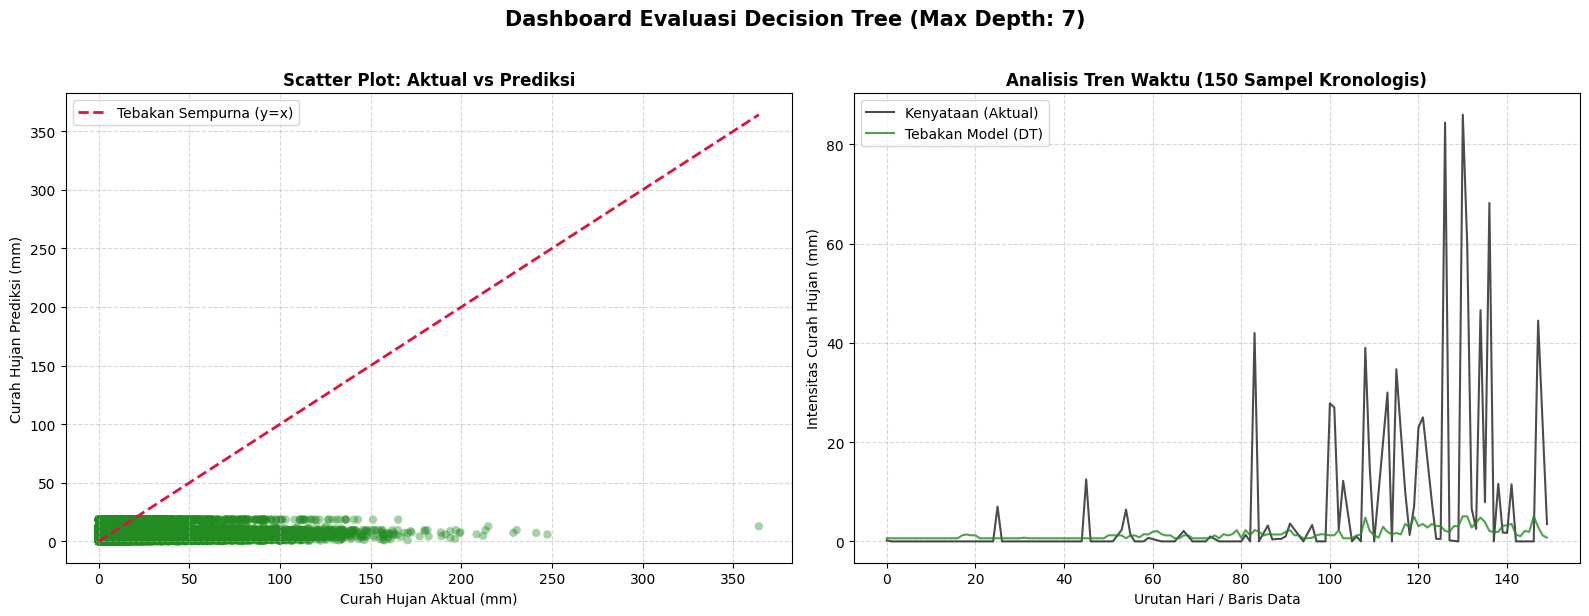

In [40]:

y_val_asli_arr = np.array(y_val_asli)
y_pred_asli_arr = np.array(y_pred_asli_dt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
axes[0].scatter(y_val_asli_arr, y_pred_asli_arr, alpha=0.4, color='forestgreen', edgecolors='none')
max_val = max(np.max(y_val_asli_arr), np.max(y_pred_asli_arr))
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2, label='Tebakan Sempurna (y=x)')
axes[0].set_title('Scatter Plot: Aktual vs Prediksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Curah Hujan Aktual (mm)', fontsize=10)
axes[0].set_ylabel('Curah Hujan Prediksi (mm)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Line Plot
jumlah_sampel = 150
axes[1].plot(y_val_asli_arr[:jumlah_sampel], label='Kenyataan (Aktual)', color='black', alpha=0.7, linewidth=1.5)
axes[1].plot(y_pred_asli_arr[:jumlah_sampel], label='Tebakan Model (DT)', color='forestgreen', alpha=0.8, linewidth=1.5)
axes[1].set_title(f'Analisis Tren Waktu ({jumlah_sampel} Sampel Kronologis)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Urutan Hari / Baris Data', fontsize=10)
axes[1].set_ylabel('Intensitas Curah Hujan (mm)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle('Dashboard Evaluasi Decision Tree (Max Depth: 7)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Dibawah kami ingin mengetahui visualisasi dari decision tree yang telah dibuat oleh model yang kami sudah jalankan. Kami ingin melihat mengapa hasil akurasi yang didapatkanya sangat rendah atau kurang baik. Dan kami ingin tahu bagaimana cara kerja decision tree dilihat dari pohon yang dibuatnya berikut kode yang kami jalankan diambil dari library yang sama untuk membuat decision tree dan mengoutput hasilnya dalam bentuk visualisasi pohon sampai kedalam 3 saja sebagiannya agar tidak terlalu besar untuk mengetahui saja bagaimana cara kerjanya.

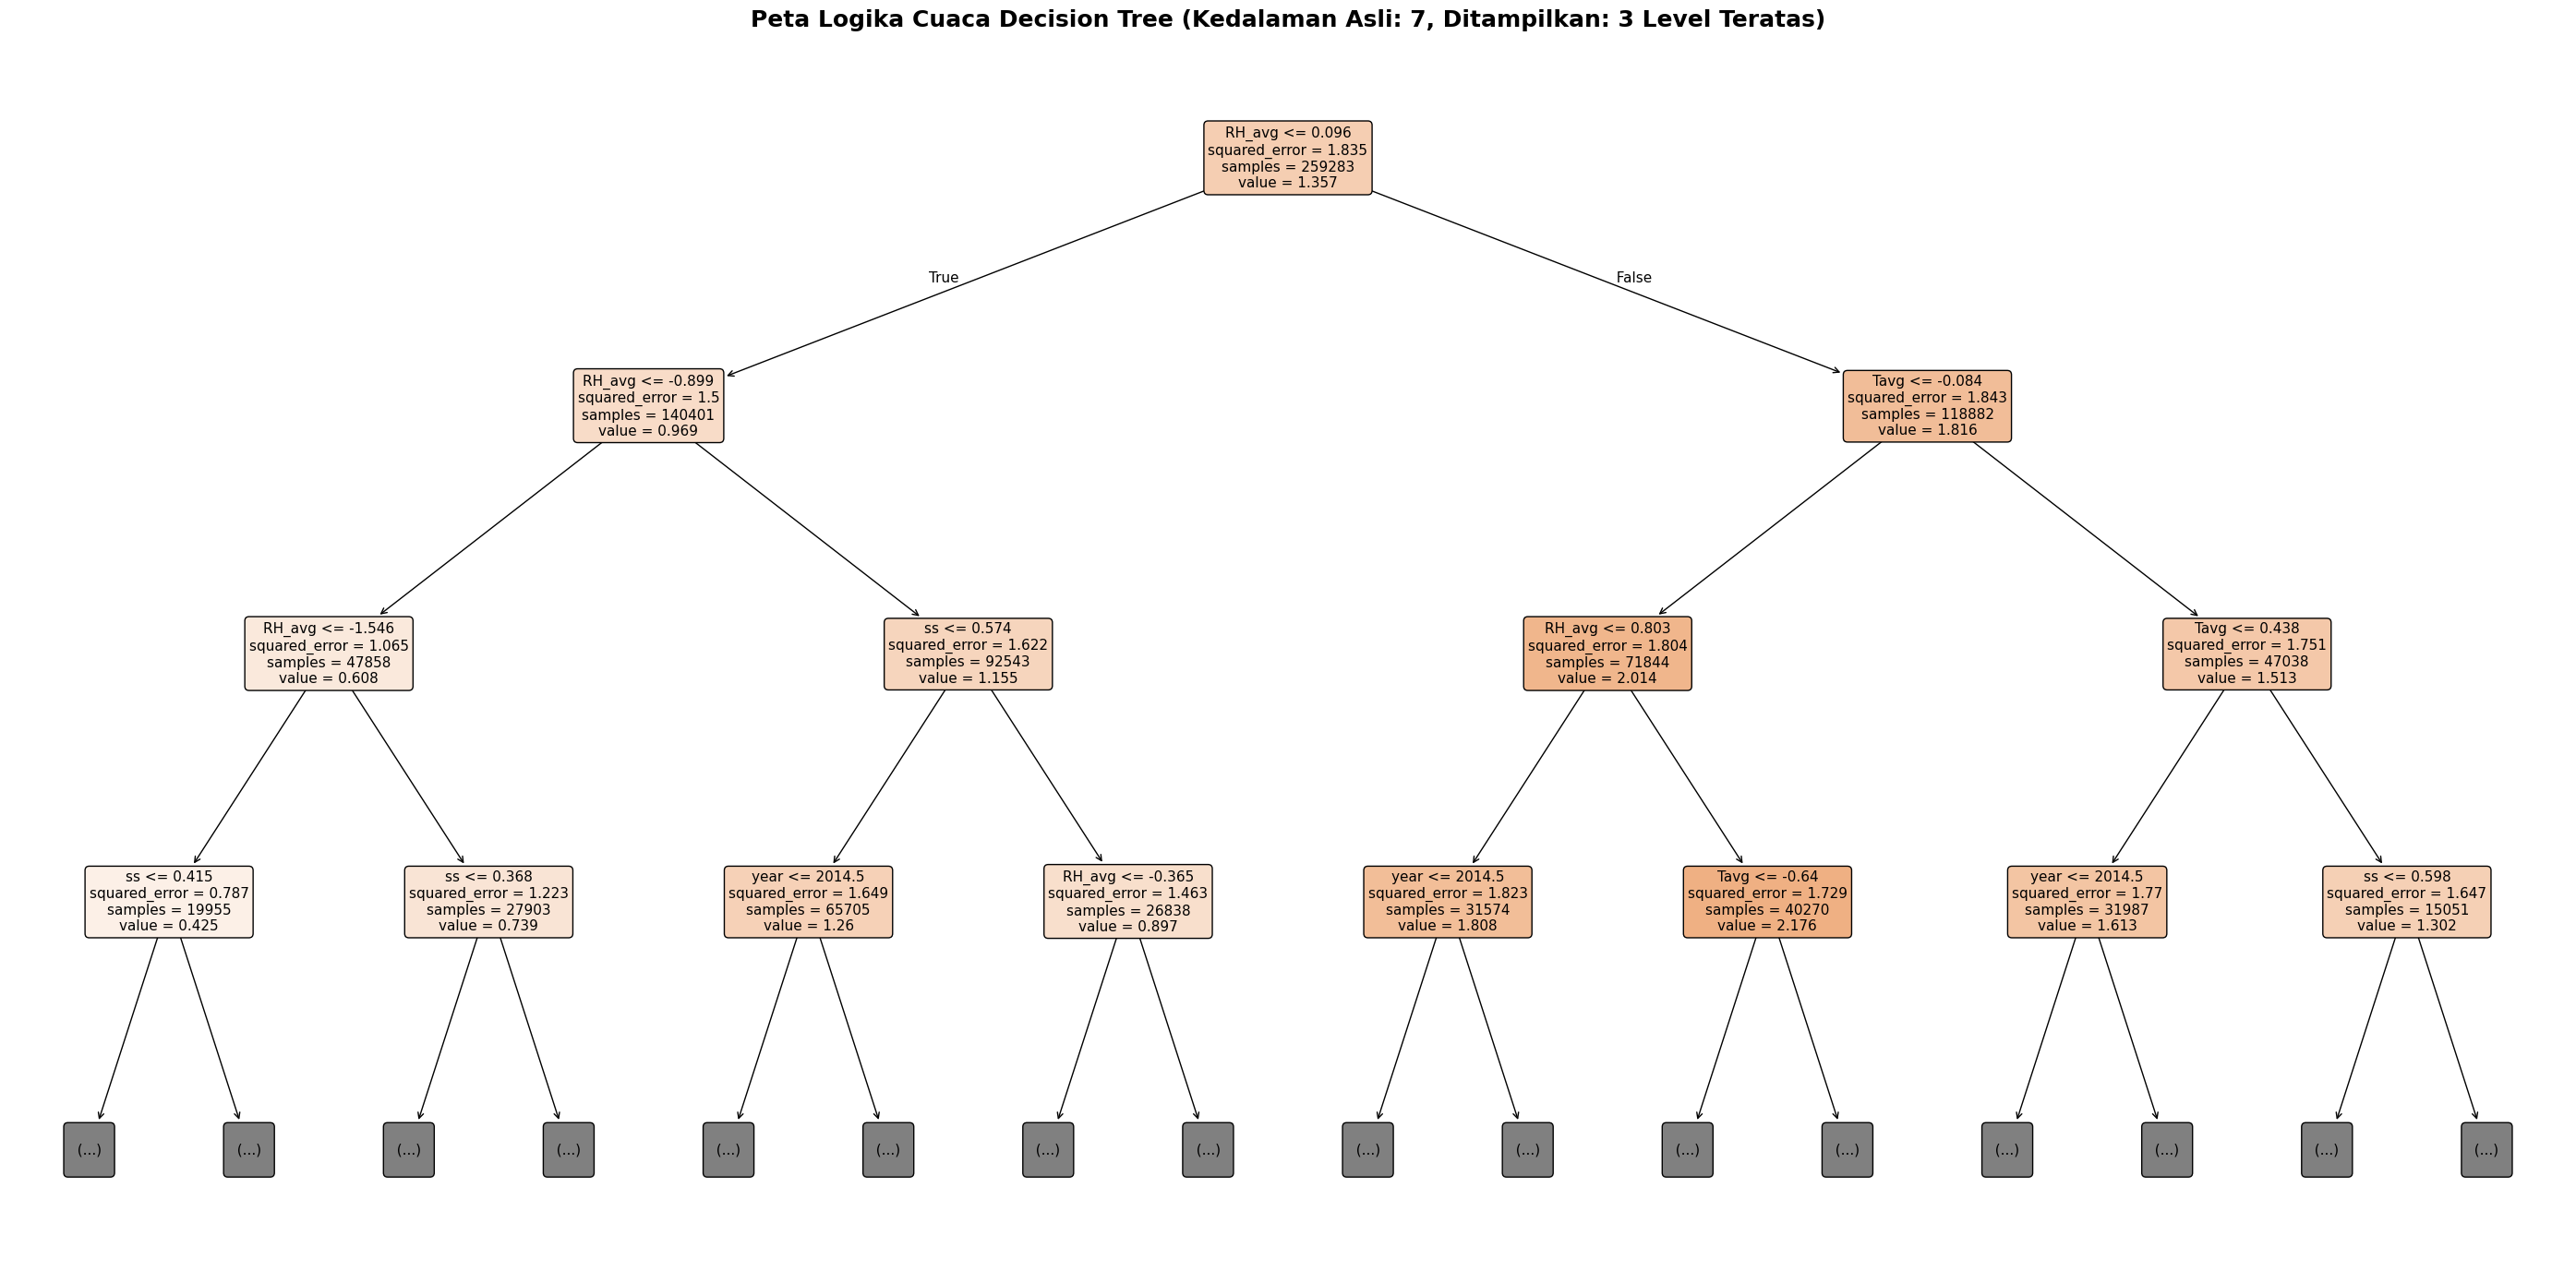

In [41]:
from sklearn.tree import plot_tree
plt.figure(figsize=(28, 14))

plot_tree(
    dt_model,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=11,
    max_depth=3
)

plt.title("Peta Logika Cuaca Decision Tree (Kedalaman Asli: 7, Ditampilkan: 3 Level Teratas)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Random Forest

Dan terakhir algoritma yang kami ingin coba adalah random forest yang merupakan extensi dari decision tree yang lebih kompleks, kami memilih algoritma ini dikarenakan mungkin algoritma yang sweet spot dimana tidak terlalu kompleks seperti gradient boosting tapi cukup robust dibandingkan decision tree. 

- Dengan mengambil rata-rata dari ratusan pohon, Random Forest menstabilkan tebakan dari singular decision tree dan membuat tebakan lebih akurat dengan mengabungkan tebakan-tebakan kecil dari masing-masing tree.
- outlier yang ekstrim dapat membuat perhitungan model menjadi kacau. Untuk random forest, outlier ini hanya akan mempengaruhi beberapa pohon saja, dan akan ditempa tebakannya oleh pohon-pohon yang lain.
- Random forest memaksa setiap pohon melihat sebagian fitur secara acak. Hal ini mencegah model menjadi terlalu bergantung pada satu fitur saja.

Hyperparameter yang dipakai oleh random forest yang disediakan oleh library sklearn adalah sebagai berikut:
| Hyperparameter | Penjelasan |
| --- | --- |
| n_estimators | banyak pohon yang akan dibuat |
| max_depth | kedalaman maksimum masing-masing pohon |
| min_sample_leaf | minimum sample data yang harus ada di leaf node |
| max_features | cara menentukan split terbaik |
| random_state | seed untuk random |

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# 1. INISIALISASI RANDOM FOREST

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=67
)

# 2. TRAINING

rf_model.fit(X_train_lasso, y_train)

# 3. PREDIKSI & INVERSE LOG KE MILIMETER

y_pred_log_rf = rf_model.predict(X_val_lasso)
y_pred_asli_rf = np.expm1(y_pred_log_rf)
y_val_asli = np.expm1(y_val)

# 4. EVALUASI

mae_rf = mean_absolute_error(y_val_asli, y_pred_asli_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_rf))
r2_rf = r2_score(y_val_asli, y_pred_asli_rf)

print("Evaluasi Random Forest")
print(f"MAE        : {mae_rf:.2f} mm")
print(f"RMSE       : {rmse_rf:.2f} mm")
print(f"R-squared  : {r2_rf:.4f}")

Evaluasi Random Forest
MAE        : 7.16 mm
RMSE       : 15.64 mm
R-squared  : 0.0069


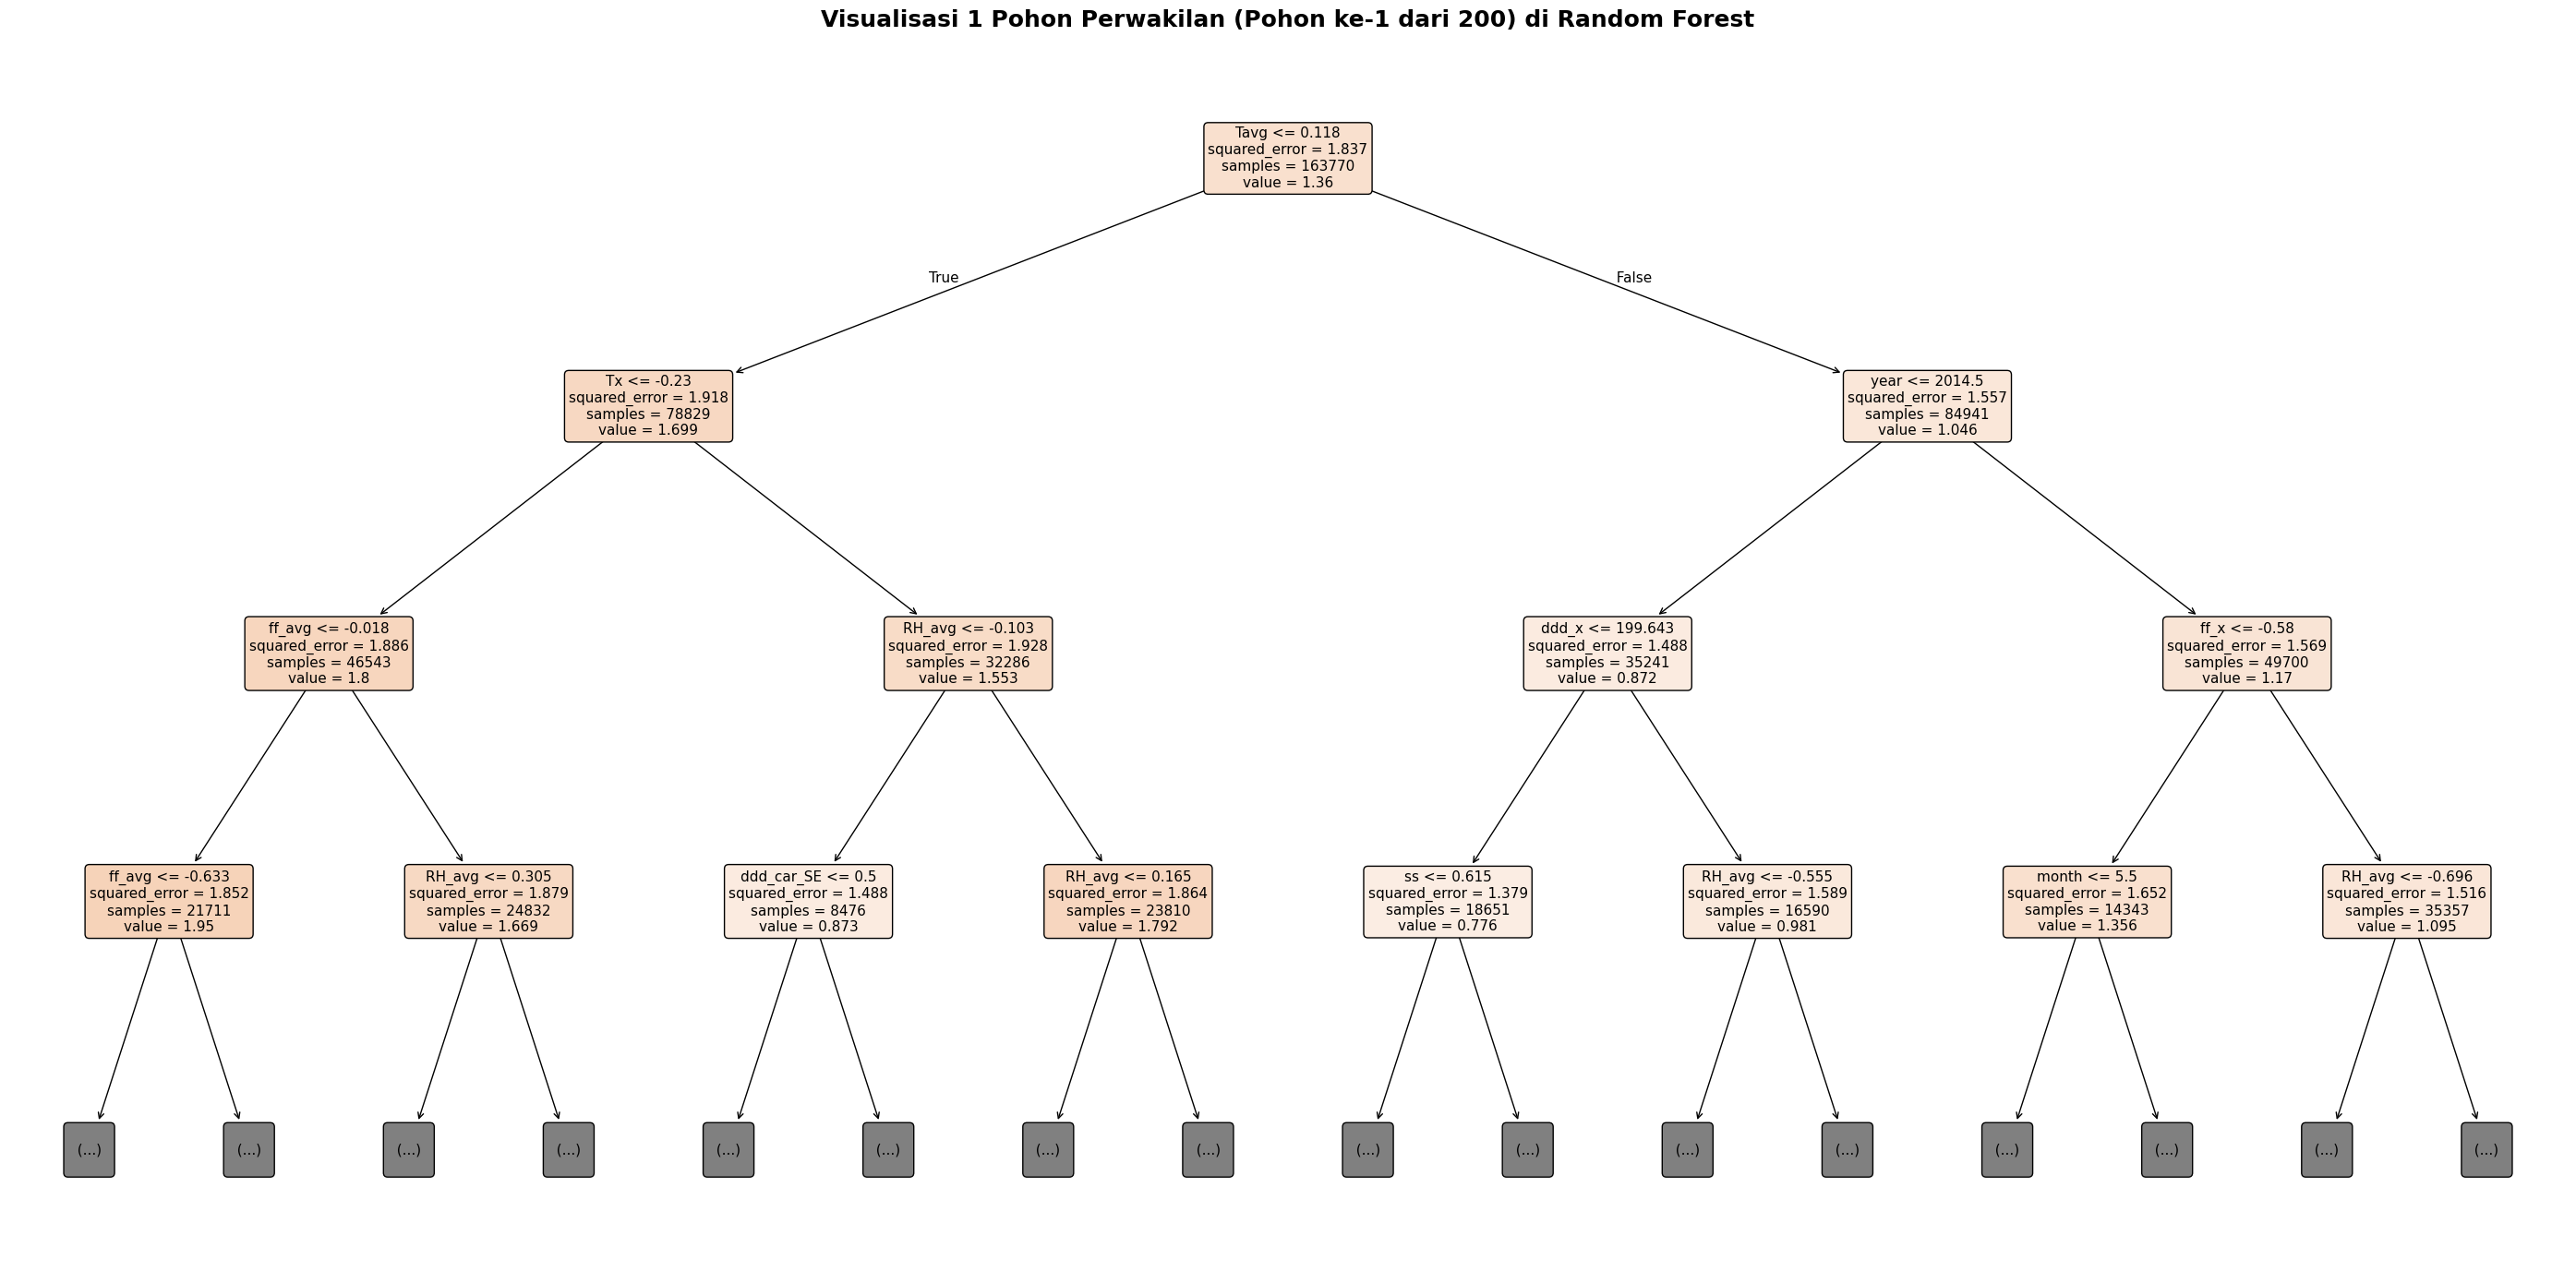

In [43]:
pohon_perwakilan = rf_model.estimators_[0]
plt.figure(figsize=(28, 14))

plot_tree(
    pohon_perwakilan,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=11,
    max_depth=3
)

plt.title("Visualisasi 1 Pohon Perwakilan (Pohon ke-1 dari 200) di Random Forest", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Dari hasil menjalankan ketiga algoritma tersebut didapatkan pemenang algoritma yang paling cocok untuk menebak tingat curah hujan yaitu adalah gradient boosting yang dapat dilihat dari hasil errornya dan juga R^2 Squared scorenya dimana algoritma ini adalah algoritma yang paling akurat untuk memberikan tebakan prediksi label Oleh karena itu kami memilih algoritma gradient boosting menjadi algortima yang akan dilakukan hyperparameter tuning untuk mendapatkan model yang lebih baik dengan hyperparameter yang paling cocok. 

# Hyperparameter Tuning

Setelah kami sudah memilih untuk menggunakan algoritma gradient boosting tahap selanjutnya adalah untuk melakukan hyperparameter tuning untuk mendapatkan model yang paling baik dengan hyperparameter tertentu, untuk mendapatkan itu kami pertama akan menggunakan evaluation metric yang sama seperti sebelumnya dan kami akan membuat sebuah gradient boosting base dan membuat grid berisi nilai-nilai untuk hyperparameter-hyperparameter. Kami memilih untuk hanya mengubah 4 hyperparameter yaitu adalah berikut:

| Hyperparameter | Value |
|----------------|-------|
| learning_rate  | 0.01  |
|                | 0.05  |
|                | 0.1   |
|                | 0.2   |
| n_estimators   | 100   |
|                | 300   |
|                | 500   |
|                | 700   |
| max_depth      | 3     |
|                | 5     |
|                | 7     |
| subsample      | 0.8   |
|                | 1     |

Kami menggunakan gridsearchCV untuk menjalankan hyperparameter tuning secara otomatis menjalankan semua permutasi dari hyperparameter yang tersedia kedalam model gradient boosting dan menampilkan hasilnya dalam bentuk sebuah data grid yang akan menunjukan masing-masing model dengan hyperparameter berbeda. Hasil grid ini akan memiliki angka dari hyperparameter model tersebut beserta juga dengan skor hasil evaluasi dari model dengan hyperparameter tersebut, evaluasi yang kami gunakan adalah MAE dan r2 score. Untuk mendapatkan pemenang dari hasil hyperparameter tuning maka test yang dilakkan tidak hanya dilakukan untuk data training saja oleh arena itu ditambahkan pada bagian gridSearchCV sebuah parameter yaitu cv = 5 yaitu adalah membuat 5 fold cross validation dimana diambil dataset kami dan dibagi menjadi 5 bagian dan 4 bagiannya menjadi training untuk para model dan 1 fold sisanya menjadi validasi. hyperparameter yang terbaik adalah yang memiliki kedua training dan validation evaluation score yang terbaik dan tidak berat sebelah lebih tarining lebih besar dibandingkan validation.

Hasil akhir gridsearchCV akhirnya di print out ke output dan diambil yang memiliki nilai kedua ini yang paling baik dan setelah itu akan dibandingkan dengan baseline hyperparameter untuk melihat apakah hyperparameter tuning dapat memperbaiki dan memperbagus model baseline. 

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import GradientBoostingRegressor

def custom_mae(y_true_log, y_pred_log):
    y_true_asli = np.expm1(y_true_log)
    y_pred_asli = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_asli, y_pred_asli)

def custom_r2(y_true_log, y_pred_log):
    y_true_asli = np.expm1(y_true_log)
    y_pred_asli = np.expm1(y_pred_log)
    return r2_score(y_true_asli, y_pred_asli)

mae_scorer = make_scorer(custom_mae, greater_is_better=False)
r2_scorer = make_scorer(custom_r2, greater_is_better=True)

gb_base = GradientBoostingRegressor(max_features='sqrt', random_state=67)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring={'MAE': mae_scorer, 'R2': r2_scorer},
    refit='R2',
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_train_lasso, y_train)

print(f"Parameter Terbaik: {grid_search.best_params_}\n")

results_df = pd.DataFrame(grid_search.cv_results_)

columns_to_keep = {
    'param_learning_rate': 'learning_rate',
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_subsample': 'subsample',
    'mean_train_MAE': 'mean_train_mae',
    'mean_test_MAE': 'mean_test_mae',
    'mean_train_R2': 'mean_train_r2',
    'mean_test_R2': 'mean_test_r2'
}

final_results_df = results_df[list(columns_to_keep.keys())].rename(columns=columns_to_keep)
final_results_df['mean_train_mae'] = final_results_df['mean_train_mae'].abs()
final_results_df['mean_test_mae'] = final_results_df['mean_test_mae'].abs()

print("GridSearchCV Results:")
print(final_results_df.to_string(index=False))

Parameter Terbaik: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}

GridSearchCV Results:
 learning_rate  n_estimators  max_depth  subsample  mean_train_mae  mean_test_mae  mean_train_r2  mean_test_r2
          0.01           100          3        0.8        8.692744       8.712412      -0.100147     -0.101806
          0.01           100          3        1.0        8.692064       8.712249      -0.099909     -0.101476
          0.01           300          3        0.8        8.476936       8.511202      -0.061512     -0.064300
          0.01           300          3        1.0        8.480832       8.515656      -0.062519     -0.065263
          0.01           500          3        0.8        8.405451       8.448461      -0.045379     -0.049021
          0.01           500          3        1.0        8.407647       8.451975      -0.045985     -0.049622
          0.01           700          3        0.8        8.370623       8.421126      -0.036801     -0

Setelah mendapatkan hyperparameter terbaik kami melakukan perbandingan dengan baseline hyperparameter sebelumnya untuk mendapatkan perbedaan diantara kedua model dan dapat dilihat bahwa hasilnya memang lebih baik akurasinya dibandingkan dengan model baseline.

In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# INISIALISASI MODEL

# Memasukkan best_params_ dari hasil Grid Search
gb_tuned = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=700,
    subsample=0.8,
    max_features='sqrt',  
    random_state=67
)


# MELATIH ULANG MODEL

gb_tuned.fit(X_train_lasso, y_train)

# TAHAP 1: VALIDATION SET

# Prediksi (hasilnya masih dalam skala log)
y_pred_log_val = gb_tuned.predict(X_val_lasso)
y_pred_asli_val = np.expm1(y_pred_log_val)
y_val_asli = np.expm1(y_val)

# Evaluasi Validasi
mae_val = mean_absolute_error(y_val_asli, y_pred_asli_val)
rmse_val = np.sqrt(mean_squared_error(y_val_asli, y_pred_asli_val))
r2_val = r2_score(y_val_asli, y_pred_asli_val)

# TAHAP 2: TESTING SET

# Prediksi (hasilnya masih dalam skala log)
y_pred_log_test = gb_tuned.predict(X_test_lasso)
y_pred_asli_test = np.expm1(y_pred_log_test)
y_test_asli = np.expm1(y_test)

# Evaluasi Testing
mae_test = mean_absolute_error(y_test_asli, y_pred_asli_test)
rmse_test = np.sqrt(mean_squared_error(y_test_asli, y_pred_asli_test))
r2_test = r2_score(y_test_asli, y_pred_asli_test)

print("Evaluasi Final Gradient Boosting Dengan Tuned Hyperparameter")

print("Hasil Validation Set:")
print(f"MAE  (Rata-rata Meleset)     : {mae_val:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_val:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_val:.4f}\n")

print("Hasil Testing Set:")
print(f"MAE  (Rata-rata Meleset)     : {mae_test:.2f} mm")
print(f"RMSE (Meleset Terburuk)      : {rmse_test:.2f} mm")
print(f"R-squared (Skor Kecerdasan)  : {r2_test:.4f}")

Evaluasi Final Gradient Boosting Dengan Tuned Hyperparameter
Hasil Validation Set:
MAE  (Rata-rata Meleset)     : 7.17 mm
RMSE (Meleset Terburuk)      : 15.54 mm
R-squared (Skor Kecerdasan)  : 0.0201

Hasil Testing Set:
MAE  (Rata-rata Meleset)     : 7.25 mm
RMSE (Meleset Terburuk)      : 15.78 mm
R-squared (Skor Kecerdasan)  : 0.0300


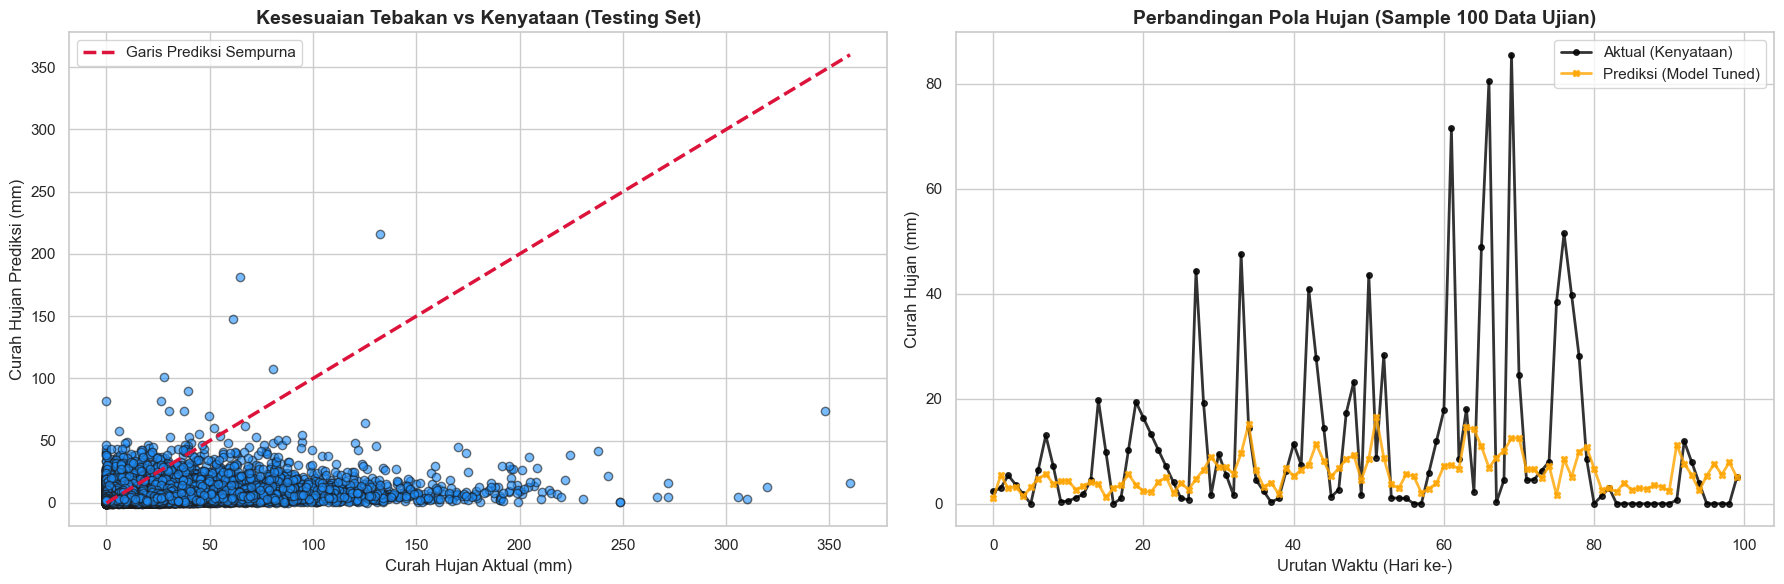

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns


# VISUALISASI HASIL TESTING SET

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GRAFIK 1: Scatter Plot (Aktual vs Prediksi)

# Menggambar titik-titik prediksi vs aktual
axes[0].scatter(y_test_asli, y_pred_asli_test, alpha=0.6, color='dodgerblue', edgecolor='k')

# Membuat garis diagonal merah
max_val = max(y_test_asli.max(), y_pred_asli_test.max())
axes[0].plot([0, max_val], [0, max_val], color='crimson', linestyle='--', linewidth=2.5, label='Garis Prediksi Sempurna')
axes[0].set_title("Kesesuaian Tebakan vs Kenyataan (Testing Set)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Curah Hujan Aktual (mm)", fontsize=12)
axes[0].set_ylabel("Curah Hujan Prediksi (mm)", fontsize=12)
axes[0].legend()


# GRAFIK 2: Line Plot

batas_visual = 100 
axes[1].plot(y_test_asli.values[:batas_visual], label='Aktual (Kenyataan)', color='black', alpha=0.8, linewidth=2, marker='o', markersize=4)
axes[1].plot(y_pred_asli_test[:batas_visual], label='Prediksi (Model Tuned)', color='orange', alpha=0.8, linewidth=2, marker='X', markersize=5)
axes[1].set_title(f"Perbandingan Pola Hujan (Sample {batas_visual} Data Ujian)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Urutan Waktu (Hari ke-)", fontsize=12)
axes[1].set_ylabel("Curah Hujan (mm)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Tabel Perbandingan Sebelum dan Sesudah Tuning


,Metrik Ujian,Sebelum Tuning,Sesudah Tuning,Selisih
0,MAE Validation (mm) ↓,7.1408,7.1671,0.0264
1,RMSE Validation (mm) ↓,15.5376,15.5361,-0.0015
2,R-Squared Validation ↑,0.0199,0.0201,0.0002
3,MAE Testing (mm) ↓,7.2191,7.2537,0.0346
4,RMSE Testing (mm) ↓,15.7882,15.7776,-0.0106
5,R-Squared Testing ↑,0.0287,0.0300,0.0013


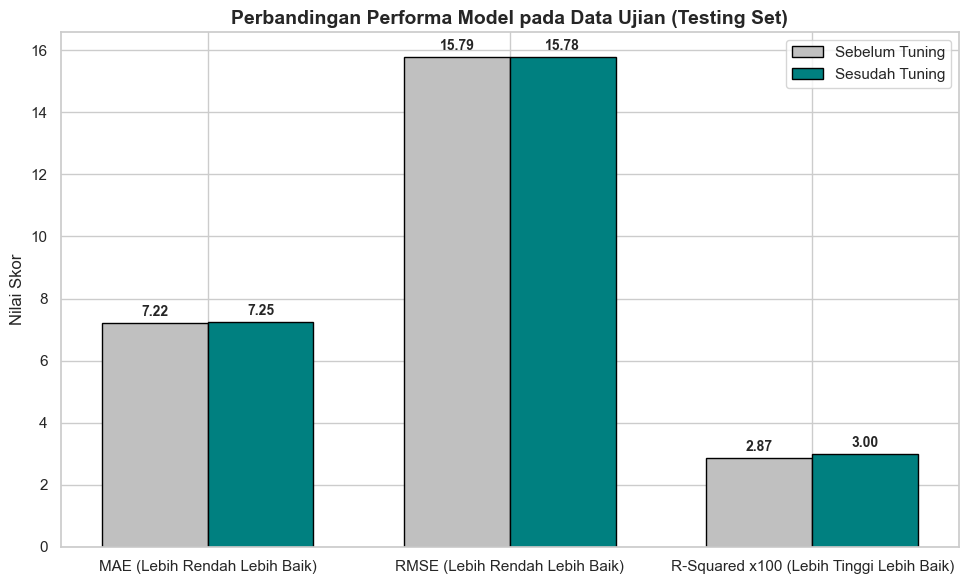

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# INISIALISASI KEDUA MODEL (STANDAR VS TUNED)

# Model 1: Standar
gb_standar = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=7, 
    min_samples_leaf=5, 
    subsample=0.8, 
    max_features='sqrt', 
    random_state=67
)

# Model 2: Tuned
gb_tuned = GradientBoostingRegressor(
    n_estimators=700, 
    learning_rate=0.1, 
    max_depth=7, 
    subsample=0.8, 
    max_features='sqrt', 
    random_state=67
)

# PELATIHAN KEDUA MODEL

gb_standar.fit(X_train_lasso, y_train)
gb_tuned.fit(X_train_lasso, y_train)

# FUNGSI EVALUASI

def evaluasi_model(model, X_data, y_true_log):
    # Prediksi
    y_pred_log = model.predict(X_data)
    # Kembalikan ke mm
    y_pred_asli = np.expm1(y_pred_log)
    y_true_asli = np.expm1(y_true_log)
    
    # Hitung metrik
    mae = mean_absolute_error(y_true_asli, y_pred_asli)
    rmse = np.sqrt(mean_squared_error(y_true_asli, y_pred_asli))
    r2 = r2_score(y_true_asli, y_pred_asli)
    return mae, rmse, r2

# Evaluasi Standar
mae_val_std, rmse_val_std, r2_val_std = evaluasi_model(gb_standar, X_val_lasso, y_val)
mae_test_std, rmse_test_std, r2_test_std = evaluasi_model(gb_standar, X_test_lasso, y_test)

# Evaluasi Tuned
mae_val_tnd, rmse_val_tnd, r2_val_tnd = evaluasi_model(gb_tuned, X_val_lasso, y_val)
mae_test_tnd, rmse_test_tnd, r2_test_tnd = evaluasi_model(gb_tuned, X_test_lasso, y_test)


# MEMBUAT TABEL PERBANDINGAN (DATAFRAME)

perbandingan_df = pd.DataFrame({
    'Metrik Ujian': [
        'MAE Validation (mm) ↓', 'RMSE Validation (mm) ↓', 'R-Squared Validation ↑',
        'MAE Testing (mm) ↓', 'RMSE Testing (mm) ↓', 'R-Squared Testing ↑'
    ],
    'Sebelum Tuning': [
        mae_val_std, rmse_val_std, r2_val_std, 
        mae_test_std, rmse_test_std, r2_test_std
    ],
    'Sesudah Tuning': [
        mae_val_tnd, rmse_val_tnd, r2_val_tnd, 
        mae_test_tnd, rmse_test_tnd, r2_test_tnd
    ]
})

# Menghitung selisih (Improvment)
perbandingan_df['Selisih'] = perbandingan_df['Sesudah Tuning'] - perbandingan_df['Sebelum Tuning']

print("Tabel Perbandingan Sebelum dan Sesudah Tuning")
display(perbandingan_df.round(4)) 

# VISUALISASI GRAFIK PERBANDINGAN UNTUK TESTING SET

labels = ['MAE (Lebih Rendah Lebih Baik)', 'RMSE (Lebih Rendah Lebih Baik)', 'R-Squared x100 (Lebih Tinggi Lebih Baik)']
std_scores = [mae_test_std, rmse_test_std, r2_test_std * 100] # R2 dikali 100 agar terlihat di grafik bersanding dengan MAE/RMSE
tnd_scores = [mae_test_tnd, rmse_test_tnd, r2_test_tnd * 100]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, std_scores, width, label='Sebelum Tuning', color='silver', edgecolor='black')
rects2 = ax.bar(x + width/2, tnd_scores, width, label='Sesudah Tuning', color='teal', edgecolor='black')

ax.set_ylabel('Nilai Skor', fontsize=12)
ax.set_title('Perbandingan Performa Model pada Data Ujian (Testing Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()

# Menambahkan angka di atas batang grafik
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# Insight

Curah hujan tidak bisa hanya sekedar ditentukan dari dataset yang kita miliki, dikarenakan ada banyak hal lain yang tidak ada dalam dataset kami dan juga tidak dapat ditangkap oleh sebuah sensor biasa dari sebuah stasiun iklim. Dari hasil ini kami mempelajari lebih lanjut mengenai apa yang membuat dan mempengaruhi tingkat curah hujan pada suatu hari, seperti formasi awan, dikarenakan awan itu beragam dengan ketinggian tertentu namun pada dataset ini kita tidak memiliki data tersebut seperti peta radar awan untuk setiap ketinggian atomsfer melainkan kami hanya memiliki dataset berupa sunshine yang menunjukan adanya awan yang menghalangi matahari namun tidak pasti awan itu berbentuk apa seperti apa dalam ketinggian apa. Selain itu pula tempratur yang dicatat oleh dataset ini adalah tempratur yang diambil dari udara spesifik di sensor spesifik dalam stasiun iklim spesifik. Melainkan suhu itu dinamis dan suhu tanah suhu laut itu sangat mempengaruhi tingkat curah hujan beserta juga lokasi dari tempratur itu seberapa jauhnya dengan tempat yang akan dihitung tingkat curah hujannya yang akan datang. Berbagai hal kecil dapat mengubah tingkat curah hujan yang akan datang, oleh karena fakta itu dataset yang kami miliki yang dilatih dengan model yang kami pilih tidak robust dan cukup lengkap untuk dapt memprediksi tingkat curah hujan, hal ini dapat dilihat dari graph scatter plot yang dibuat untuk menghitung akurasi model yang masih sangat jauh dari kata sempurna. 

Hal menarik lainnya yang kami dapatkan adalah untuk fitur yang berpengaruh terhadap curah hujan menggambarkan dunia nyata dimana ss atau sunshine memang benar berbanding terbalik dengan curah hujan dan juga kelembapan tentu saja sangat berpengaruh terhadap curah hujan. Hal menarik terakhir adalah dengan arah mata angin paling banyak ddd_car dimana ada sebagian keberanan untuk intuisi dimana angin muson barat membawa hujan sedangnkan timur membawa kemarau hal ini pun ditambah kebenarannya dengan perhitungan awal pada eksperimen ini yang mencoba melakukan plotting antara bulan dan curah hujan memberikan sedikit gambaran kedua musim kemarau dan hujan yang dialami di iklim tropis

# Kesimpulan

Model terbaik yang berhasil kami latih adalah gradient boosting dikarenakan gradient boosting adalah algoritma yang cocok dengan dataset yang kami miliki ditambah juga dengan berbagai hyperparameter yang dapat diubah dan disesuikan dengan kebutuhan dataset kami oleh karen itu gradient boosting menjadi model yang paling cocok. Gradient boosting juga sesuai dengan kebutuh dataset kami yang tidak dapat ditebah oleh sebuah regressor linear oleh karena itu gradient boosting ini dapat lebih mendekati persebaran dataset kami yang tidak terlalu berbentuk sempurna yang dapat dilihat dari graph-graph fitur dan kolom yang kami telah buat.

Namun pada akhirnya performa gradient boosting meskipun yang paling baik dibandingkan dengan model yang lain saat diberikan testing dengan dataset yang berbeda angkanya tidak terlalu memuaskan akurasinya belum terlalu sempurna dikarenakan menebak cuaca atau tingkat curah hujan bukanlah hal yang mudah dikarenakan datasetnya juga yang tidak terlalu lengkap dan dapat menangkap secara detil ke-kompleksan dari curah hujan.

Insight utama yang didapat adalah bahwa meskipun dataset belum terlalu lengkap untuk secara akurat mendapatkan prediksi hujan, namun dapat dilihat beberapa fitur yang lumayan berhubungan dengan tingkat curah hujan yang dapat dilihat di graph setelah melakukan L1 norm, dimana sunshine yaitu adalah seberapa dalam suatu hari mendapatkan cahaya cukup berpengaruh terhadap curah hujan dan secara intuisi pun masuk akal dikarenakan bila langit memang kosong tidak ada awan maka curah hujan pun biasanya 0, setelah itu kelembapan pun berpengaruh terhadap curah hujan dikarenakan kelembapan sangat berhubungan dengan akan adanya suatu hujan. Dan yang menarik adalah arah mata angin cukup berpengaruh terhadap curah hujan dan dapat dilihat juga pada pemahaman dataset diawal yang berhubungan dengan perbandingan bulan dengan curah hujan dapat dilihat bahwa, intuisi sosial bahwa angin muson barat membawa hujan dan angin muson timur membawah musim kemarau memang ada benarnya dan hubungannya pada dataset yang kami ambil. 

Saran untuk pengembangan penilitian kami adalah untuk menambah informasi lebih banyak untuk dataset dan memodelkannya menjadi lebih besar dan menjalankan lebih banyak eksperimen lagi dengan berbagai algoritma regresi.  

